# Figure 6 — Grid-cell phenomenology

Run the cells in order, then rerun plotting cells to adjust appearance.
The model uses the **full construction** (`max_hidden_width=None`).

All output is under
`artifacts/constructed_networks/discrete_se2_c6/paper_figures/figure6/`:

- `panela/` through `panelf/`: SVG figures (optionally PDF).
- **`cache/`**: one visible, shared cache for tuning, trajectories, embeddings,
  and persistent homology. Model-specific subfolders prevent mixing configurations.
- Panel C's galleries are displayed and saved automatically in `panelc/`.

Panel F follows the supplied computation: 256-neuron batches, 32-drive batches,
global tuning, then the chosen PCA/UMAP method. Homology uses full-population
distances. Its camera starts at elevation 24.4°, azimuth 141.3°.

## 1. Imports

Run inside the repository, or set `PROJECT_ROOT` below. The path is added before
any `src` imports. Install missing dependencies once using the commented command.

In [1]:
# Run once in your environment if needed:
# %pip install numpy scipy matplotlib torch scikit-learn umap-learn ripser pandas plotly

from pathlib import Path
from dataclasses import asdict, dataclass
from collections import defaultdict
import gc
import hashlib
import html
import importlib.metadata
import json
import sys
import time

PROJECT_ROOT = None  # Optional: Path('/absolute/path/to/grids-and-groups')
project_root = Path(PROJECT_ROOT).expanduser().resolve() if PROJECT_ROOT else next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / 'src/experiments/discrete_se2.py').is_file()), None
)
if project_root is None or not (project_root / 'src').is_dir():
    raise FileNotFoundError('Set PROJECT_ROOT to your grids-and-groups repository.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle, Rectangle, Wedge
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from umap import UMAP
from ripser import ripser
from IPython.display import HTML, display

from src.analysis.tuning import compute_one_step_tuning, occupancy_normalized_activity
from src.experiments.discrete_se2 import (
    DiscreteSE2ExperimentConfig, DiscreteSE2RolloutConfig,
    build_discrete_se2_experiment, run_discrete_se2_rollout,
)
from src.geometry.discrete_se2.core import lattice_path_coordinates, lattice_path_segments
from src.geometry.discrete_se2.plotting import plot_lattice_scalar
from src.geometry.discrete_se2.trajectories import (
    NaturalisticMotionConfig, make_naturalistic_motion_sequence,
)
from src.groups.znxzn_cm import DiscreteSE2Group

plt.rcParams.update({'svg.fonttype': 'none', 'pdf.fonttype': 42})

## 2. Settings and output folders

Choose modules and display settings here. Local tuning averages the 21 local
actions; global tuning averages all group elements. `RUN_PROFILE='smoke'` runs
a small full model and writes to `smoke/figure6/` for a quick check.

In [ ]:
RUN_PROFILE = 'paper'  # 'paper' or 'smoke'
EXPORT_FORMATS = ('svg',)  # ('svg', 'pdf') exports both
SHOW_FIGURES = True
USE_DISK_CACHE = True
PRECOMPUTE_TUNING = True
RUN_INTERACTIVE = False
DEVICE = 'auto'  # 'auto', 'cpu', or 'cuda'; float64 is retained
TORCH_THREADS = 4  # Avoid oversubscribing a notebook CPU
UNIT_BATCH_SIZE = 256
DRIVE_BATCH_SIZE = 16

MODEL = dict(n_spatial=21, n_orientations=6, initial_pose=(2, 2, 0),
             max_hidden_width=None, encoding_seed=10)
PANEL_A = dict(steps=143, seed=3, margin=1, display_shift=(3, 0),
               vertical_gap=0.035, cmap='jet')
PANEL_B = dict(sheet_radius=3, orbit_frequency=(2, 0), bank_rows=4,
               bank_columns=4, bank_skip=0, gap=0.06)
PANEL_C = dict(rhos=(9, 19, 20, 21), scope='local',
               sample_counts=(100, 1_000, 5_000), steps=110, burn_in=10,
               seed=101, trajectory_batch_size=8,
               save_units_per_rho=24,  # Integer or 'all'; includes the displayed reference
               display_labels={},    # e.g. {19: {'delta': 1, 'k0': 2}}
               extra_labels={})      # e.g. {19: [{'delta': 2, 'k0': 4}]}
PANEL_D = dict(rho=21, scope='local', eps1=1, eps2=1, k1=0, k2=0,
               allow_inversion=False, delta_values=(0, 1, 2), k0_values=tuple(range(6)))
PANEL_E = dict(scope='local', threshold=1e-2,
               unit_filter={'eps1': 1, 'eps2': 1, 'k1': 0},
               example_rhos={'Spatial only': (44, 45, 46, 11, 12, 13),
                             'Conjunctive': (19, 20), 'Orientation only': None})
PANEL_F = dict(rho=9, scope='global', embedding_method='umap',
               unit_batch_size=256, drive_batch_size=32,
               pca_dimensions=9, umap_neighbors=30, umap_min_dist=0.15,
               random_seed=101, ph_max_points=None,  # None = all n² positions
               elevation=24.4, azimuth=141.3, surface=True, wireframe=True,
               max_bars=40, background_alpha=0.50)

if RUN_PROFILE not in {'paper', 'smoke'}:
    raise ValueError('RUN_PROFILE must be paper or smoke.')
if RUN_PROFILE == 'smoke':
    MODEL.update(n_spatial=7, max_hidden_width=None)
    PANEL_A.update(steps=24, display_shift=(0, 0))
    PANEL_C.update(rhos=(6, 7, 8, 9), sample_counts=(20, 40, 80), steps=25, burn_in=5)
    PANEL_D.update(rho=6)
    PANEL_E['example_rhos'] = {c: None for c in PANEL_E['example_rhos']}
    PANEL_F.update(rho=6)

if any(fmt not in {'svg', 'pdf'} for fmt in EXPORT_FORMATS) or not EXPORT_FORMATS:
    raise ValueError('EXPORT_FORMATS must contain svg and/or pdf.')
if PANEL_C['scope'] != 'local':
    raise ValueError('Panel C uses local random walks: keep its exact scope local.')

figure_parent = project_root / 'artifacts/constructed_networks/discrete_se2_c6/paper_figures'
figure_root = figure_parent / ('smoke/figure6' if RUN_PROFILE == 'smoke' else 'figure6')
panel_dirs = {letter: figure_root / f'panel{letter}' for letter in 'abcdef'}
for directory in panel_dirs.values():
    directory.mkdir(parents=True, exist_ok=True)
cache_root = figure_root / 'cache'
cache_root.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(TORCH_THREADS)
print(f'Profile: {RUN_PROFILE}; figure folder: {figure_root}')
print(f'Shared cache: {cache_root}')

## 3. Shared helpers

Exact tuning is reused across panels and cached by drive scope and neuron ID.
Display normalization affects plots only. Autocorrelation is circular,
mean-centered, and normalized to one at zero lag. The extra plotting roll
centers zero lag in the offset lattice chart.

In [3]:
def fingerprint(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, default=str).encode()).hexdigest()[:20]


def write_npz(path, **arrays):
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix('.tmp')
    with temporary.open('wb') as handle:
        np.savez_compressed(handle, **arrays)
    temporary.replace(path)


def save_panel(figure, panel, stem, *, show=None, tight=True):
    """Export the same figure in every requested vector format."""
    for fmt in EXPORT_FORMATS:
        path = panel_dirs[panel] / f'{stem}.{fmt}'
        with plt.rc_context({'savefig.bbox': None}):
            figure.savefig(path, bbox_inches='tight' if tight else None, facecolor='white')
        print(f'Saved: {path.relative_to(figure_root)}')
    if SHOW_FIGURES and show is not False:
        plt.show()
    plt.close(figure)


def display_normalized(values):
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    if not finite.any():
        return np.full_like(values, np.nan)
    low, high = values[finite].min(), values[finite].max()
    return (values - low) / max(high - low, 1e-15)


def periodic_autocorrelation(curve):
    curve = np.asarray(curve, dtype=float)
    centered = curve - curve.mean()
    energy = np.sum(centered**2)
    if not np.isfinite(energy) or energy == 0:
        return np.full_like(curve, np.nan)
    correlation = np.fft.ifft2(np.abs(np.fft.fft2(centered))**2).real
    return np.fft.fftshift(correlation / correlation[0, 0])


def plot_autocorrelation(curve, axis):
    ac = periodic_autocorrelation(curve)
    ac = np.roll(ac, -((ac.shape[1] // 2) // 2), axis=0)
    return plot_lattice_scalar(ac, ax=axis, cmap='coolwarm', vmin=-1, vmax=1,
                               colorbar=False, coordinate_mode='offset', wrap_periodic_edges=True)


def plot_orientation_pizza(values, ax, color, deviation_scale):
    values = np.asarray(values, dtype=float)
    radii = np.clip(0.5 + 0.45 * (values - values.mean()) / max(deviation_scale, 1e-15), 0, 1)
    step = 360 / len(values)
    for index, radius in enumerate(radii):
        start = index * step - step / 2
        ax.add_patch(Wedge((0, 0), 1, start, start + step,
                          facecolor='#F2F2F2', edgecolor='white', linewidth=0.7))
        ax.add_patch(Wedge((0, 0), radius, start + 1, start + step - 1,
                          facecolor=color, edgecolor='white', linewidth=0.4))
        angle = np.deg2rad(index * step)
        ax.text(1.18 * np.cos(angle), 1.18 * np.sin(angle), rf'${index * step:g}^\circ$',
                ha='center', va='center', fontsize=15)
    ax.add_patch(Circle((0, 0), 0.5, fill=False, edgecolor='0.25', linewidth=2, linestyle='--'))
    ax.set(xlim=(-1.32, 1.32), ylim=(-1.32, 1.32), aspect='equal', xticks=[], yticks=[])
    ax.spines[:].set_visible(False)


LABEL_NAMES = ('eps1', 'eps2', 'delta', 'k0', 'k1', 'k2')
CLASSES = ('Spatial only', 'Conjunctive', 'Orientation only')
PIZZA_COLORS = {'Spatial only': '#4477AA', 'Conjunctive': '#CC6677', 'Orientation only': '#228833'}


def unit_with_labels(rho, *, eps1=1, eps2=1, delta=0, k0=0, k1=0, k2=0):
    key = (int(rho), eps1, eps2, delta, k0, k1, k2)
    if key not in unit_lookup:
        raise ValueError(f'No neuron with labels {key}; check retained modules and the width budget.')
    return unit_lookup[key]


def module_units(rho):
    result = tuple(u for u, labels in enumerate(experiment.model.metadata)
                   if int(labels['irrep_index']) == rho)
    if not result:
        raise ValueError(f'Module {rho} is absent. Increase MODEL["max_hidden_width"] or choose another module.')
    return result


@dataclass
class TuningSummary:
    unit_indices: np.ndarray
    position_mean: np.ndarray  # (n, n, unit)
    heading_mean: np.ndarray  # (m, unit)
    scope: str


class TuningCache:
    """Compute only missing (scope, unit) pairs and retain compact marginals."""
    def __init__(self, experiment, directory):
        self.experiment = experiment
        self.directory = directory
        self.data = {}
        self.computed_units = defaultdict(int)
        self.drives = {
            'local': tuple(sorted(experiment.local_egocentric_elements)),
            'global': tuple(experiment.group.elements()),
        }

    def get(self, units, scope):
        units = tuple(dict.fromkeys(map(int, units)))
        if scope not in self.drives or not units:
            raise ValueError('Request nonempty units and scope local or global.')
        if scope not in self.data:
            self.data[scope] = {}
            path = self.directory / f'tuning_{scope}.npz'
            if USE_DISK_CACHE and path.exists():
                with np.load(path, allow_pickle=False) as saved:
                    position, heading = saved['position'], saved['heading']
                    for j, u in enumerate(saved['units']):
                        self.data[scope][int(u)] = (position[..., j].copy(), heading[..., j].copy())
                print(f'Loaded {len(self.data[scope]):,} cached {scope} maps.')
        bank = self.data[scope]
        missing = [u for u in units if u not in bank]
        if missing:
            started = time.perf_counter()
            print(f'Computing {len(missing):,} {scope} maps using {len(self.drives[scope]):,} drives...')
            for first in range(0, len(missing), UNIT_BATCH_SIZE):
                result = compute_one_step_tuning(
                    self.experiment, missing[first:first + UNIT_BATCH_SIZE],
                    self.drives[scope], drive_batch_size=DRIVE_BATCH_SIZE,
                )
                heading = result.pose_mean.reshape(
                    self.experiment.group.m, self.experiment.group.n,
                    self.experiment.group.n, len(result.unit_indices),
                ).mean(axis=(1, 2))
                for j, u in enumerate(result.unit_indices):
                    bank[int(u)] = (result.position_mean[..., j].copy(), heading[:, j].copy())
                self.computed_units[scope] += len(result.unit_indices)
                del result
            if USE_DISK_CACHE:
                ordered = sorted(bank)
                write_npz(self.directory / f'tuning_{scope}.npz', units=np.asarray(ordered),
                          position=np.stack([bank[u][0] for u in ordered], axis=-1),
                          heading=np.stack([bank[u][1] for u in ordered], axis=-1))
            print(f'Finished {scope} tuning in {time.perf_counter() - started:.1f} s.')
        return TuningSummary(np.asarray(units), np.stack([bank[u][0] for u in units], axis=-1),
                             np.stack([bank[u][1] for u in units], axis=-1), scope)

## 4. Build the full model

Build once and reuse it for all panels. At n=21, the full model's persistent
buffers occupy about 11 GiB, with higher peak memory during construction.
The cache key includes the model, project source, device, and library versions.

In [ ]:
for old_name in ('tuning_cache', 'experiment'):
    globals().pop(old_name, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

configuration = DiscreteSE2ExperimentConfig(
    **MODEL, allocentric_encoding='gaussian space custom orientation', sigma=1.0,
    custom_orientation_weights=(1.0, 0.8, 0.4, 0.2, 0.4, 0.8), action_side='right',
    irrep_selection='power', normalize_power_by_dim=True, always_include_trivial=True,
    power_ranking='power', q_rho=3, amplitude_mode='balanced',
    amplitude_multipliers=(1.0, 1.0, 1.0), materialize_mix=False,
)
started = time.perf_counter()
experiment = build_discrete_se2_experiment(configuration)
device = ('cuda' if torch.cuda.is_available() else 'cpu') if DEVICE == 'auto' else DEVICE
experiment.model.to(device)
n = experiment.group.n
buffer_gib = sum(b.numel() * b.element_size() for b in experiment.model.buffers()) / 2**30
print(f'Built n={n}, H={experiment.model.hidden_dim:,} on {device} in {time.perf_counter() - started:.1f} s.')
print(f'Persistent buffers: {buffer_gib:.2f} GiB; width budget: {MODEL["max_hidden_width"]}.')
print('Retained modules:', experiment.model.selected_irrep_indices)

unit_lookup = {
    (int(labels['irrep_index']), *(int(labels[key]) for key in LABEL_NAMES)): unit
    for unit, labels in enumerate(experiment.model.metadata)
}
source_hash = hashlib.sha256()
for source in sorted((project_root / 'src').rglob('*.py')):
    source_hash.update(str(source.relative_to(project_root)).encode())
    source_hash.update(source.read_bytes())
package_versions = {name: importlib.metadata.version(name)
                    for name in ('numpy', 'torch', 'matplotlib', 'scipy', 'scikit-learn', 'umap-learn', 'ripser')}
model_key = fingerprint({'config': asdict(configuration), 'source': source_hash.hexdigest(),
                         'versions': package_versions, 'device': str(device),
                         'cache_schema': 2, 'dtype': str(experiment.model.W_in.dtype)})
model_cache_dir = cache_root / model_key
model_cache_dir.mkdir(parents=True, exist_ok=True)
tuning_cache = TuningCache(experiment, model_cache_dir)
(model_cache_dir / 'settings.json').write_text(
    json.dumps({'model': asdict(configuration), 'versions': package_versions,
                'device': str(device)}, indent=2, default=str), encoding='utf-8')
print(f'Data cache for this model: {model_cache_dir}')

local_random_walk = NaturalisticMotionConfig(
    stay_probability=1 / 7, forward_probability=1 / 7,
    forward_left_or_right_probability=1 / 7, backward_left_or_right_probability=1 / 7,
    backward_probability=1 / 7, turn_probability=1 / 3, turn_persistence=0,
    wall_lookahead=1, wall_avoidance_strength=0, minimum_wall_weight=1,
    periodic_boundaries=True,
)
natural_motion = NaturalisticMotionConfig(
    stay_probability=0.05, forward_probability=0.625,
    forward_left_or_right_probability=0.1175, backward_left_or_right_probability=0.0125,
    backward_probability=0.065, turn_probability=0.12, turn_persistence=0.275,
    wall_lookahead=3, wall_avoidance_strength=2.0, minimum_wall_weight=0.05,
    periodic_boundaries=False,
)

## 5. Shared tuning for C–E

Compute the requested union once per drive scope. Later requests fill only
missing neurons. Panel F keeps its supplied batch order and has its own
population cache in the same visible `cache/` folder.

In [5]:
def panel_e_units():
    filters = PANEL_E['unit_filter']
    return tuple(u for u, labels in enumerate(experiment.model.metadata)
                 if all(int(labels[key]) == value for key, value in filters.items()))


tuning_requests = defaultdict(set)
tuning_requests[PANEL_C['scope']].update(unit_with_labels(rho) for rho in PANEL_C['rhos'])
tuning_requests[PANEL_D['scope']].update(module_units(PANEL_D['rho']))
tuning_requests[PANEL_E['scope']].update(panel_e_units())
for scope, units_requested in tuning_requests.items():
    print(f'{scope}: {len(units_requested):,} requested neurons')
    if PRECOMPUTE_TUNING:
        tuning_cache.get(sorted(units_requested), scope)

local: 10,422 requested neurons
Computing 10,422 local maps using 21 drives...
Finished local tuning in 10.9 s.


## Panel A — Trajectory

Run and decode the RNN using the forward-biased, wall-avoiding motion policy.
Cache the plotted arrays and errors. The first recorded sample is labelled
step 0; the spatial shift only chooses the display seam.

In [6]:
def compute_panel_a():
    cfg = PANEL_A
    key = fingerprint({'rollout': {key: cfg[key] for key in ('steps', 'seed', 'margin')},
                       'motion': asdict(natural_motion)})
    path = model_cache_dir / f'trajectory_{key}.npz'
    if USE_DISK_CACHE and path.exists():
        with np.load(path, allow_pickle=False) as stored:
            result = {name: stored[name] for name in stored.files}
        print('Panel A: loaded cached recurrent rollout.')
    else:
        rollout_config = DiscreteSE2RolloutConfig(
            steps=cfg['steps'], seed=cfg['seed'], margin=cfg['margin'],
            start_xy=(n // 2, n // 2), arrow_stride=2, snapshot_steps=(),
        )
        started = time.perf_counter()
        rollout = run_discrete_se2_rollout(experiment, rollout_config, natural_motion)
        result = {name: np.asarray(getattr(rollout, name)) for name in (
            'exact_centers', 'predicted_centers', 'exact_poses', 'predicted_poses',
            'center_errors', 'orientation_errors', 'relative_output_errors',
        )}
        del rollout
        if USE_DISK_CACHE:
            write_npz(path, **result)
        print(f'Panel A rollout: {time.perf_counter() - started:.1f} s.')
    print(f'Max position error: {result["center_errors"].max():.3g}; '
          f'max heading error (rad): {result["orientation_errors"].max():.3g}; '
          f'max relative output error: {result["relative_output_errors"].max():.3g}')
    return result


panel_a_data = compute_panel_a()

Panel A rollout: 54.0 s.
Max position error: 0; max heading error (rad): 0; max relative output error: 3.25e-12


### A. Plot and save

Position and heading share one time color scale. `vertical_gap` controls their
separation; seam-crossing spatial segments are omitted.

Saved: panela/trajectory.svg


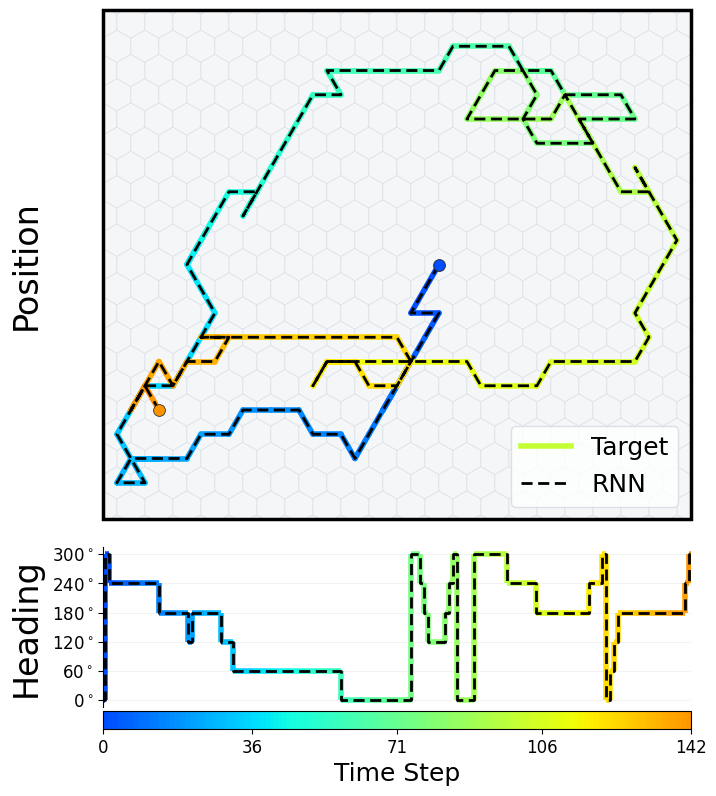

In [7]:
def plot_panel_a(data):
    n_spatial, n_orientations = experiment.group.n, experiment.group.m
    def path_segments(points, n):
        """Consecutive segments, excluding jumps across the plotting seam."""
        coordinates = lattice_path_coordinates(points, n, mode="offset")
        segments = np.stack((coordinates[:-1], coordinates[1:]), axis=1)
        keep = np.linalg.norm(np.diff(coordinates, axis=0), axis=1) <= 1.5
        segment_times = np.arange(len(coordinates) - 1) + 0.5
        return segments[keep], segment_times[keep]


    def heading_segments(steps, heading):
        """Horizontal and vertical segments of a mid-step heading trace."""
        boundaries = np.r_[
            steps[0], (steps[:-1] + steps[1:]) / 2, steps[-1]
        ]
        horizontal = np.stack(
            (
                np.column_stack((boundaries[:-1], heading)),
                np.column_stack((boundaries[1:], heading)),
            ),
            axis=1,
        )
        vertical = np.stack(
            (
                np.column_stack((boundaries[1:-1], heading[:-1])),
                np.column_stack((boundaries[1:-1], heading[1:])),
            ),
            axis=1,
        )
        return (
            np.concatenate((horizontal, vertical)),
            np.concatenate((steps, boundaries[1:-1])),
        )


    # Data from the current rollout.
    display_shift = np.asarray(PANEL_A['display_shift'])
    exact_centers = (np.asarray(data["exact_centers"]) - display_shift) % n_spatial
    predicted_centers = (
        np.asarray(data["predicted_centers"]) - display_shift
    ) % n_spatial

    true_heading = 360 * np.asarray(data["exact_poses"])[:, 2] / n_orientations
    decoded_heading = 360 * np.asarray(data["predicted_poses"])[:, 2] / n_orientations

    # Zero-based indexing of the recorded samples.
    steps = np.arange(len(true_heading))
    time_normalization = mcolors.Normalize(steps[0], steps[-1])

    # Appearance.
    time_colormap = mcolors.LinearSegmentedColormap.from_list(
        "light_time",
        plt.colormaps[PANEL_A['cmap']](np.linspace(0.20, 0.75, 256)),
    )
    grid_facecolor = "#F4F6F8"
    grid_edgecolor = "#D4DAE2"
    decoded_color = "black"
    vertical_gap = PANEL_A['vertical_gap']
    arena_border_width = 2.5

    # Match the spatial plot's physical aspect ratio.
    figure_7 = plt.figure(figsize=(7, 8), layout="none")
    left, right = 0.13, 0.97
    spatial_height = (
        figure_7.get_figwidth() / figure_7.get_figheight()
        * (right - left) * np.sqrt(3) / 2
    )
    spatial_bottom = 0.96 - spatial_height

    trajectory_ax = figure_7.add_axes(
        (left, spatial_bottom, right - left, spatial_height)
    )
    heading_height = 0.20
    heading_bottom = spatial_bottom - vertical_gap - heading_height
    heading_ax = figure_7.add_axes(
        (left, heading_bottom, right - left, heading_height)
    )
    colorbar_ax = figure_7.add_axes(
        (left, heading_bottom - 0.027, right - left, 0.022)
    )

    plot_lattice_scalar(
        np.zeros((n_spatial, n_spatial)),
        ax=trajectory_ax,
        cmap=mcolors.ListedColormap([grid_facecolor]),
        vmin=0, vmax=1, colorbar=False,
        coordinate_mode="offset", wrap_periodic_edges=True,
    )
    trajectory_ax.collections[-1].set(
        edgecolor=grid_edgecolor, linewidth=0.35
    )

    # A patch remains visible when the lattice renderer hides the axes.
    trajectory_ax.add_patch(Rectangle(
        (0, 0), 1, 1,
        transform=trajectory_ax.transAxes,
        fill=False, edgecolor="black",
        linewidth=arena_border_width,
        clip_on=False, zorder=10,
    ))

    segments, segment_times = path_segments(exact_centers, n_spatial)
    spatial_trace = LineCollection(
        segments,
        cmap=time_colormap, norm=time_normalization,
        array=segment_times, linewidth=4, capstyle="round",
    )
    trajectory_ax.add_collection(spatial_trace)

    for segment in lattice_path_segments(
        predicted_centers, n_spatial, mode="offset"
    ):
        trajectory_ax.plot(
            segment[:, 0], segment[:, 1],
            color=decoded_color, linewidth=2,
            linestyle=(0, (4, 2)),
        )

    exact_display = lattice_path_coordinates(
        exact_centers, n_spatial, mode="offset"
    )
    trajectory_ax.scatter(
        *exact_display[0], s=72, marker="o",
        color=time_colormap(0.0),
        edgecolors="#29323C", linewidths=0.7, zorder=5,
    )
    trajectory_ax.scatter(
        *exact_display[-1], s=72, marker="o",
        color=time_colormap(1.0),
        edgecolors="#29323C", linewidths=0.6, zorder=5,
    )

    true_line, = trajectory_ax.plot(
        [], [], color=time_colormap(0.7), linewidth=4,
        label="Target",
    )
    decoded_line, = trajectory_ax.plot(
        [], [], color=decoded_color, linewidth=2,
        linestyle=(0, (4, 2)), label="RNN",
    )
    trajectory_ax.legend(
        handles=[true_line, decoded_line],
        loc="lower right", frameon=True, facecolor="white",
        edgecolor=grid_edgecolor, fontsize=18,
    )

    segments, segment_times = heading_segments(steps, true_heading)
    heading_ax.add_collection(LineCollection(
        segments,
        cmap=time_colormap, norm=time_normalization,
        array=segment_times, linewidth=4,
    ))
    heading_ax.step(
        steps, decoded_heading, where="mid",
        color=decoded_color, linewidth=2,
        linestyle=(0, (4, 2)),
    )

    heading_ticks = np.arange(n_orientations) * 360 / n_orientations
    heading_ax.set(
        xlim=(steps[0], steps[-1]),
        ylim=(-15, heading_ticks[-1] + 15),
        yticks=heading_ticks,
        yticklabels=[rf"${angle:g}^\circ$" for angle in heading_ticks],
    )
    heading_ax.tick_params(axis="x", bottom=False, labelbottom=False)
    heading_ax.tick_params(axis="y", labelsize=12)
    heading_ax.grid(axis="y", alpha=0.18, linewidth=0.6)
    heading_ax.spines[["top", "right", "bottom"]].set_visible(False)

    # Colorbar doubles as the heading plot's time axis.
    colorbar = figure_7.colorbar(
        spatial_trace, cax=colorbar_ax, orientation="horizontal",
    )
    colorbar.set_ticks(
        np.linspace(steps[0], steps[-1], 5).round().astype(int)
    )
    colorbar.set_label("Time Step", fontsize=18)
    colorbar.outline.set_visible(True)
    colorbar_ax.tick_params(axis="x", labelsize=12)

    for axis, label in (
        (trajectory_ax, "Position"),
        (heading_ax, "Heading"),
    ):
        axis.annotate(
            label,
            xy=(-0.13, 0.5),
            xycoords="axes fraction",
            rotation=90,
            ha="center", va="center",
            fontsize=24,
            annotation_clip=False,
        )

    save_panel(figure_7, 'a', 'trajectory')

plot_panel_a(panel_a_data)

## Panel B — Characters and rotation orbits

Export the plane-wave character bank, the six selected orbit members, their sum,
and a bank of unique orbit sums. These maps are evaluated directly from the
characters, so no model tuning is needed.

Saved: panelb/character_bank.svg


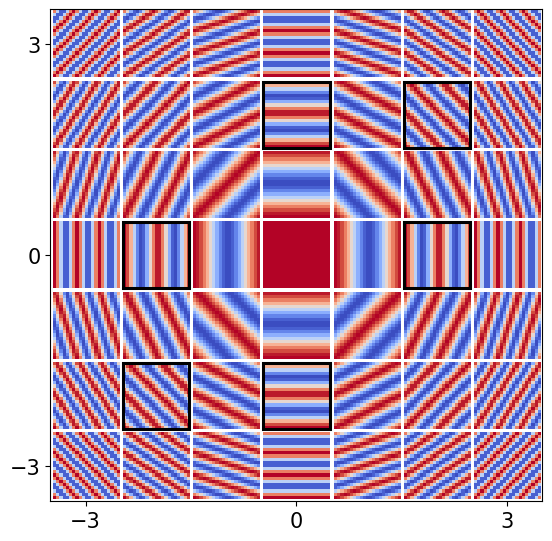

Saved: panelb/orbit_character_kx_0_ky_-2.svg
Saved: panelb/orbit_character_kx_0_ky_2.svg
Saved: panelb/orbit_character_kx_-2_ky_0.svg
Saved: panelb/orbit_character_kx_2_ky_0.svg
Saved: panelb/orbit_character_kx_-2_ky_-2.svg
Saved: panelb/orbit_character_kx_2_ky_2.svg
Saved: panelb/orbit_sum.svg


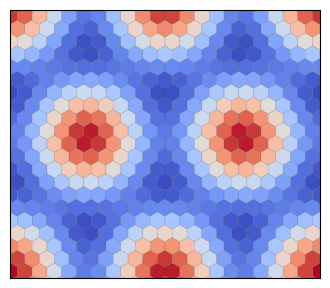

Saved: panelb/unique_orbit_sums.svg


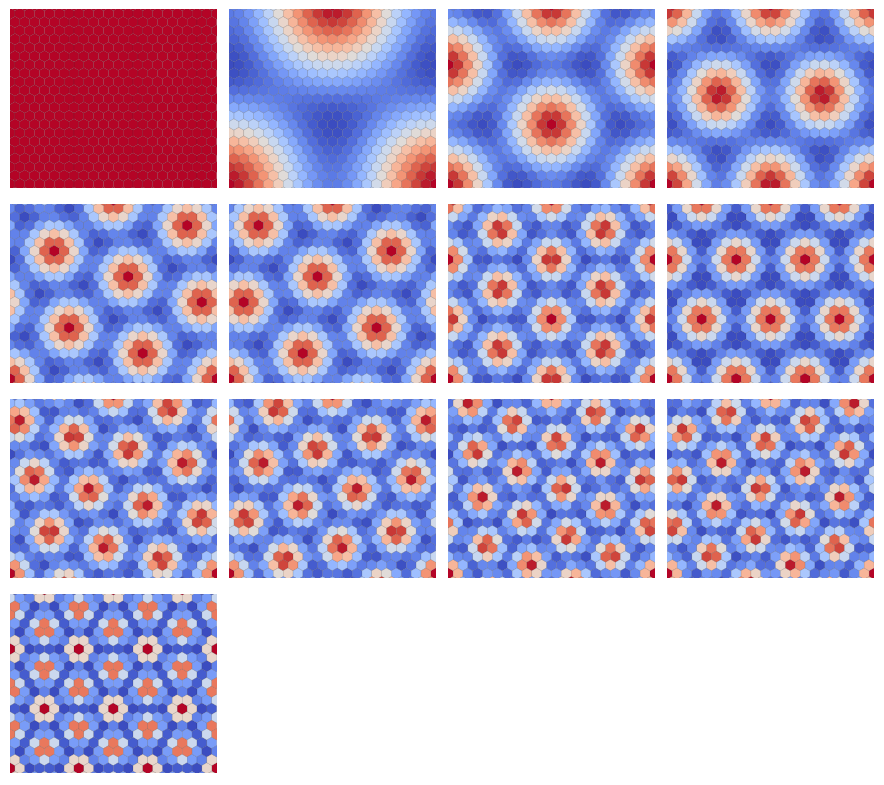

In [8]:
def plot_panel_b():
    group = DiscreteSE2Group(n, 6)
    sheet_frequencies = np.arange(-PANEL_B['sheet_radius'], PANEL_B['sheet_radius'] + 1)
    y, x = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    cmap = "coolwarm"
    gap = PANEL_B['gap']


    def character(k):
        return np.cos(2 * np.pi * (k[0] * x + k[1] * y) / n)


    def centered(k):
        return tuple(
            (int(value) + n // 2) % n - n // 2
            for value in k
        )


    def pair_key(k):
        return tuple(sorted((centered(k), centered((-k[0], -k[1])))))


    orbit = tuple(
        centered(k)
        for k in next(
            candidate
            for candidate in group.orbit_dict()[6]
            if tuple(value % n for value in PANEL_B['orbit_frequency']) in candidate
        )
    )

    conjugate_pairs = list(dict.fromkeys(pair_key(k) for k in orbit))
    ordered_orbit = tuple(k for pair in conjugate_pairs for k in pair)


    def square_axes(size):
        figure = plt.figure(figsize=(size, size), layout="none")
        axis = figure.add_axes((0.14, 0.14, 0.82, 0.82))
        axis.tick_params(labelsize=9)
        return figure, axis


    def save_svg(figure, filename, show=True, tight=False):
        save_panel(figure, 'b', Path(filename).stem, show=show, tight=tight)


    # 1. Character bank with whitespace and black selection outlines.
    figure, bank = square_axes(6.0)
    tile_width = 1 - gap

    for ky in sheet_frequencies:
        for kx in sheet_frequencies:
            bank.imshow(
                character((kx, ky)),
                origin="lower",
                extent=(
                    kx - tile_width / 2,
                    kx + tile_width / 2,
                    ky - tile_width / 2,
                    ky + tile_width / 2,
                ),
                cmap=cmap,
                vmin=-1,
                vmax=1,
                interpolation="nearest",
            )

    for k in orbit:
        bank.add_patch(Rectangle(
            (k[0] - tile_width / 2, k[1] - tile_width / 2),
            tile_width,
            tile_width,
            fill=False,
            edgecolor="black",
            linewidth=2.2,
            zorder=3,
        ))

    limits = (sheet_frequencies[0] - 0.5, sheet_frequencies[-1] + 0.5)
    bank.set(
        xlim=limits,
        ylim=limits,
        xticks=(sheet_frequencies[0], 0, sheet_frequencies[-1]),
        yticks=(sheet_frequencies[0], 0, sheet_frequencies[-1]),
    )
    bank.tick_params(axis="both", labelsize=15)
    bank.set_aspect("equal", adjustable="box")

    save_svg(figure, "character_bank.svg")


    # 2. Six individual orbit heatmaps, each with a black border.
    for k in ordered_orbit:
        figure, axis = square_axes(3.0)

        axis.imshow(
            character(k),
            origin="lower",
            cmap=cmap,
            vmin=-1,
            vmax=1,
            interpolation="nearest",
            aspect="equal",
        )
        axis.set(
            xticks=([]),
            yticks=([]),
        )

        for spine in axis.spines.values():
            spine.set(color="black", linewidth=2.5)

        save_svg(
            figure,
            f"orbit_character_kx_{k[0]}_ky_{k[1]}.svg",
            show=False,
        )


    # 3. Orbit sum with the original lattice geometry and coordinate limits.
    figure, axis = plt.subplots(figsize=(4.0, 4.0), layout="none")
    combined = sum(character(k) for k in orbit)

    plot_lattice_scalar(
        display_normalized(combined),
        ax=axis,
        title="",
        cmap=cmap,
        vmin=0,
        vmax=1,
        colorbar=False,
        coordinate_mode="offset",
        wrap_periodic_edges=True,
    )

    axis.set_axis_on()
    axis.set(title="", xlabel="", ylabel="")
    axis.tick_params(labelsize=15)
    axis.set(xticks=([]), yticks=([]))

    save_svg(figure, "orbit_sum.svg", tight=True)


    orbit_lookup = {}
    for orbit_family in group.orbit_dict().values():
        for candidate in orbit_family:
            orbit = tuple(sorted(centered(k) for k in candidate))
            for k in orbit:
                orbit_lookup[k] = orbit

    unique_orbits = list(dict.fromkeys(
        orbit_lookup[centered((kx, ky))]
        for ky in sheet_frequencies
        for kx in sheet_frequencies
    ))

    unique_orbits.sort(
        key=lambda orbit: min(kx**2 + ky**2 for kx, ky in orbit)
    )

    figure, axes = plt.subplots(PANEL_B['bank_rows'], PANEL_B['bank_columns'], figsize=(9, 8), squeeze=False)
    figure.subplots_adjust(
        left=0.02, right=0.98, bottom=0.02, top=0.98,
        wspace=0.06, hspace=0.06,
    )

    for axis in axes.flat:
        axis.set_axis_off()

    for axis, orbit in zip(axes.flat, unique_orbits[PANEL_B['bank_skip']:PANEL_B['bank_skip'] + axes.size]):
        combined = sum(
            np.cos(2 * np.pi * (kx * x + ky * y) / n)
            for kx, ky in orbit
        )
        normalized = (
            display_normalized(combined)
            if np.ptp(combined) > 0
            else np.ones_like(combined)
        )

        plot_lattice_scalar(
            normalized,
            ax=axis,
            title="",
            cmap="coolwarm",
            vmin=0,
            vmax=1,
            colorbar=False,
            coordinate_mode="offset",
            wrap_periodic_edges=True,
        )
        axis.set_axis_off()

    save_panel(figure, 'b', 'unique_orbit_sums')

plot_panel_b()

## Panel C — Empirical tuning

Accumulate actual recurrent activity along one nested stream of trajectories.
At each sample count, save activity sums, occupancies, and neuron IDs to
`cache/<model>/empirical_<settings>/checkpoint_<count>.npz`.
Unvisited bins remain blank after occupancy normalization.

`save_units_per_rho=24` retains 24 neurons from each module; use `'all'` for every
neuron. `display_labels` selects the main figure's rows, and `extra_labels` adds
specific neurons to the saved bank. Adding new neurons reuses the same trajectory
schedule. Increasing the bank does not change the main figure's row count.

In [ ]:
def displayed_c_units():
    return tuple(unit_with_labels(rho, **PANEL_C['display_labels'].get(rho, {}))
                 for rho in PANEL_C['rhos'])


def requested_c_units():
    chosen = set(displayed_c_units())
    count = PANEL_C['save_units_per_rho']
    for rho in PANEL_C['rhos']:
        available = module_units(rho)
        reference = unit_with_labels(rho)
        chosen.add(reference)
        remainder = [u for u in available if u != reference]
        if count == 'all':
            chosen.update(remainder)
        elif isinstance(count, int) and count >= 1:
            indices = np.linspace(0, len(remainder) - 1, min(count - 1, len(remainder))).astype(int)
            chosen.update(remainder[i] for i in indices)
        else:
            raise ValueError('save_units_per_rho must be a positive integer or all.')
        chosen.update(unit_with_labels(rho, **labels)
                      for labels in PANEL_C['extra_labels'].get(rho, []))
    return tuple(sorted(chosen))


def empirical_checkpoints(units, cfg):
    """Stream real recurrent trajectories once for all requested checkpoints."""
    units = tuple(map(int, units))
    counts = tuple(sorted(set(map(int, cfg['sample_counts']))))
    retained = cfg['steps'] - cfg['burn_in']
    if not units or len(set(units)) != len(units):
        raise ValueError('Request a nonempty sequence of distinct neurons.')
    if not counts or cfg['burn_in'] < 0 or retained < 1 or any(count < 1 or count % retained for count in counts):
        raise ValueError('Sample counts must be positive multiples of steps - burn_in.')
    if cfg['trajectory_batch_size'] < 1:
        raise ValueError('trajectory_batch_size must be positive.')
    settings = {key: cfg[key] for key in ('steps', 'burn_in', 'seed', 'trajectory_batch_size')}
    key = fingerprint({'settings': settings, 'motion': asdict(local_random_walk), 'schema': 1})
    directory = model_cache_dir / f'empirical_{key}'
    directory.mkdir(parents=True, exist_ok=True)
    bank = {}
    complete = set(units)
    for count in counts:
        path = directory / f'checkpoint_{count}.npz'
        if USE_DISK_CACHE and path.exists():
            with np.load(path, allow_pickle=False) as saved:
                bank[count] = {k: saved[k] for k in saved.files}
            complete.intersection_update(map(int, bank[count]['units']))
        else:
            complete.clear()
    missing = tuple(u for u in units if u not in complete)
    if missing:
        total_trajectories = counts[-1] // retained
        rng = np.random.default_rng(cfg['seed'])
        # Interleaving seed and start draws makes prefixes independent of total count.
        schedules = [(int(rng.integers(0, np.iinfo(np.int32).max)),
                      tuple(map(int, rng.integers(0, n, size=2))))
                     for _ in range(total_trajectories)]
        sums = np.zeros((n, n, len(missing)), dtype=np.float64)
        occupancy = np.zeros((n, n), dtype=np.int64)
        print(f'Panel C: {len(missing)} neurons, {total_trajectories} trajectories, checkpoints {counts}.')
        for first in range(0, total_trajectories, cfg['trajectory_batch_size']):
            last = min(first + cfg['trajectory_batch_size'], total_trajectories)
            sequences = np.stack([
                make_naturalistic_motion_sequence(
                    experiment.group, steps=cfg['steps'], seed=schedules[i][0],
                    start_xy=schedules[i][1], initial_pose=configuration.initial_pose,
                    margin=0, action_side=configuration.action_side, config=local_random_walk,
                ) for i in range(first, last)
            ])
            with torch.no_grad():
                activity = experiment.model.selected_hidden_rollout(
                    experiment.x_allo, sequences, missing,
                ).detach().cpu().numpy()
            for local_index, sequence in enumerate(sequences):
                pose = experiment.group.encode(*configuration.initial_pose)
                positions = []
                for action in sequence:
                    pose = experiment.group.compose(pose, int(action))
                    positions.append(experiment.group.decode(pose)[:2])
                positions = np.asarray(positions)[cfg['burn_in']:]
                kept_activity = activity[local_index, cfg['burn_in']:]
                if not np.isfinite(kept_activity).all():
                    raise ValueError('Nonfinite empirical activity; inspect recurrent rollout stability.')
                np.add.at(sums, tuple(positions.T), kept_activity)
                np.add.at(occupancy, tuple(positions.T), 1)
                count = (first + local_index + 1) * retained
                if count in counts:
                    old = bank.get(count)
                    if old is not None:
                        np.testing.assert_array_equal(old['occupancy'], occupancy)
                        keep = ~np.isin(old['units'], missing)
                        saved_units = np.r_[old['units'][keep], missing]
                        saved_sums = np.concatenate((old['activity_sums'][..., keep], sums), axis=-1)
                    else:
                        saved_units, saved_sums = np.asarray(missing), sums.copy()
                    order = np.argsort(saved_units)
                    bank[count] = {'units': saved_units[order],
                                   'activity_sums': saved_sums[..., order].copy(),
                                   'occupancy': occupancy.copy()}
                    if USE_DISK_CACHE:
                        write_npz(directory / f'checkpoint_{count}.npz', **bank[count])
                    print(f'  Saved checkpoint {count:,}; occupied bins {np.count_nonzero(occupancy)}/{n*n}.')
            del activity
    else:
        print(f'Panel C: loaded all {len(units)} requested neurons at every checkpoint.')
    curves = {}
    for count in counts:
        lookup = {int(u): j for j, u in enumerate(bank[count]['units'])}
        columns = [lookup[u] for u in units]
        curves[count] = occupancy_normalized_activity(
            bank[count]['activity_sums'][..., columns], bank[count]['occupancy'], min_occupancy=1)
    return {'units': units, 'curves': curves, 'counts': counts,
            'occupancy': {count: bank[count]['occupancy'] for count in counts},
            'cache_directory': directory}


panel_c_data = empirical_checkpoints(requested_c_units(), PANEL_C)
print('Empirical checkpoints:', panel_c_data['cache_directory'])

### C. Main figure

Show empirical maps, local one-step tuning, and autocorrelation. The one-step
map is shifted by the known initial template center to match arena coordinates.
Choose different saved neurons through `PANEL_C['display_labels']`.

Saved: panelc/empirical_one_step_autocorrelation.svg


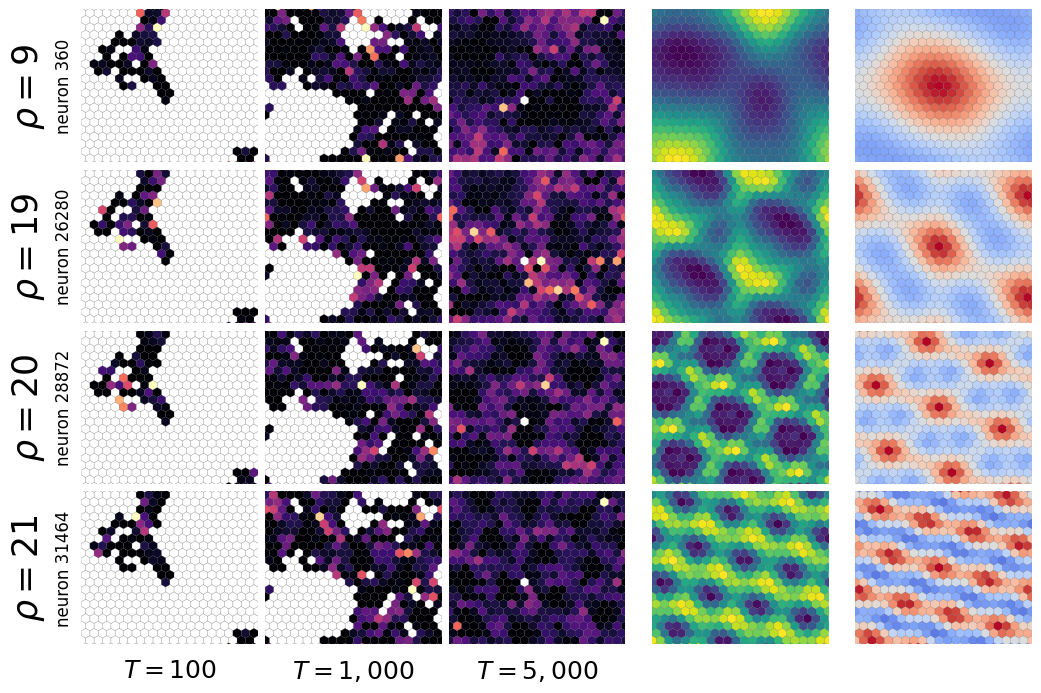

In [10]:
def plot_panel_c(data):
    row_rhos = PANEL_C["rhos"]
    row_units = displayed_c_units()
    sample_counts = data["counts"]
    missing = set(row_units) - set(data["units"])
    if missing:
        raise ValueError("Selected neurons are not cached: rerun the Panel C computation cell.")
    empirical_index = {u: j for j, u in enumerate(data["units"])}
    empirical_curves = {u: [data["curves"][count][..., empirical_index[u]] for count in sample_counts]
                        for u in row_units}
    exact_tuning = tuning_cache.get(row_units, PANEL_C["scope"])
    if configuration.initial_pose[2] != 0:
        raise ValueError("Panel C display conversion currently requires initial heading zero.")
    small_gap = 0.04
    large_gap = 0.15
    row_gap = 0.05
    nrows = len(row_units)
    widths = []
    for column in range(len(sample_counts) + 2):
        if column:
            widths.append(small_gap if column < len(sample_counts) else large_gap)
        widths.append(1)

    figure = plt.figure(figsize=(10.5, 5.7), layout="none")
    figure.subplots_adjust(
        left=0.085, right=0.99, bottom=0.10, top=0.97,
        wspace=0, hspace=0,
    )

    grid = figure.add_gridspec(
        nrows, len(widths),
        width_ratios=widths,
        wspace=0, hspace=row_gap,
    )
    axes = np.array([
        [figure.add_subplot(grid[row, col]) for col in range(0, len(widths), 2)]
        for row in range(nrows)
    ])

    for row, (rho, unit) in enumerate(
        zip(row_rhos, row_units, strict=True)
    ):
        exact_curve = exact_tuning.position_mean[..., row]
        curves = empirical_curves[unit] + [
            np.roll(exact_curve, configuration.initial_pose[:2], axis=(0, 1))
        ]

        for column, curve in enumerate(curves):
            plot_lattice_scalar(
                display_normalized(curve),
                ax=axes[row, column],
                cmap="magma" if column < len(sample_counts) else "viridis",
                vmin=0, vmax=1, colorbar=False,
                coordinate_mode="offset", wrap_periodic_edges=True,
            )

        plot_autocorrelation(exact_curve, axes[row, -1])

        axes[row, 0].annotate(
            rf"$\rho={rho}$",
            (-0.3, 0.5), xycoords="axes fraction",
            rotation=90, ha="center", va="center", fontsize=25,
        )
        axes[row, 0].annotate(
            f"neuron {unit}",
            (-0.10, 0.5), xycoords="axes fraction",
            rotation=90, ha="center", va="center", fontsize=12,
        )

    # Time labels beneath the bottom row.
    for column, samples in enumerate(sample_counts):
        axes[-1, column].annotate(
            rf"$T={samples:,}$",
            (0.5, 0), xycoords="axes fraction",
            xytext=(0, -10), textcoords="offset points",
            ha="center", va="top", fontsize=18,
            annotation_clip=False,
        )

    p = figure.subplotpars
    figure.set_figheight(
        figure.get_figwidth()
        * (p.right - p.left) / (p.top - p.bottom)
        * (nrows + row_gap * (nrows - 1)) / sum(widths)
        * axes[0, 0].get_data_ratio()
    )

    save_panel(figure, 'c', 'empirical_one_step_autocorrelation')


plot_panel_c(panel_c_data)

### C. Saved neuron galleries

Display and save **every gallery page for every configured module** at the largest
empirical checkpoint. Filenames include the module, page offset, and sample count.
Tile labels are neuron ID and $(\epsilon_1,\epsilon_2,\delta;k_0,k_1,k_2)$.
Enable individual exports below if you also want a separate file per neuron.

Saved: panelc/empirical_gallery_rho_9_offset_0_N_5000.svg


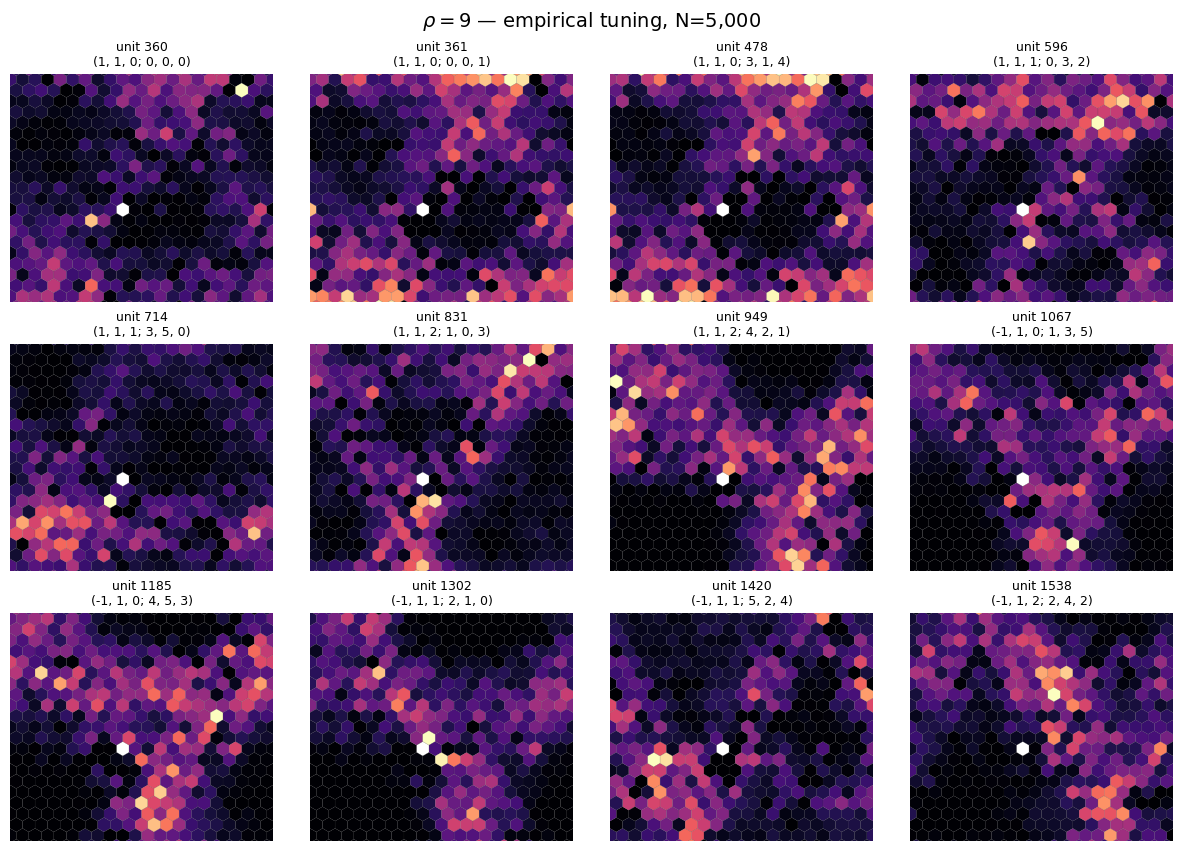

Saved: panelc/empirical_gallery_rho_9_offset_12_N_5000.svg


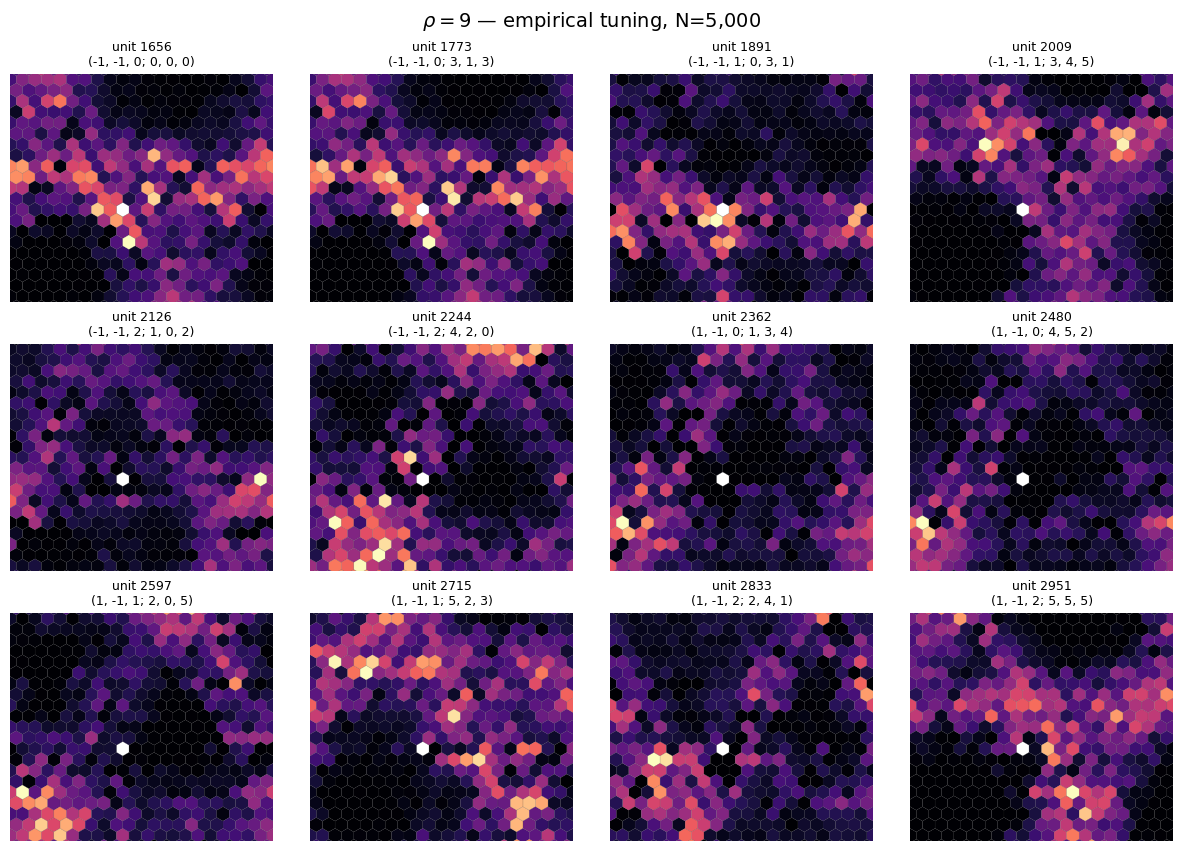

Saved: panelc/empirical_gallery_rho_19_offset_0_N_5000.svg


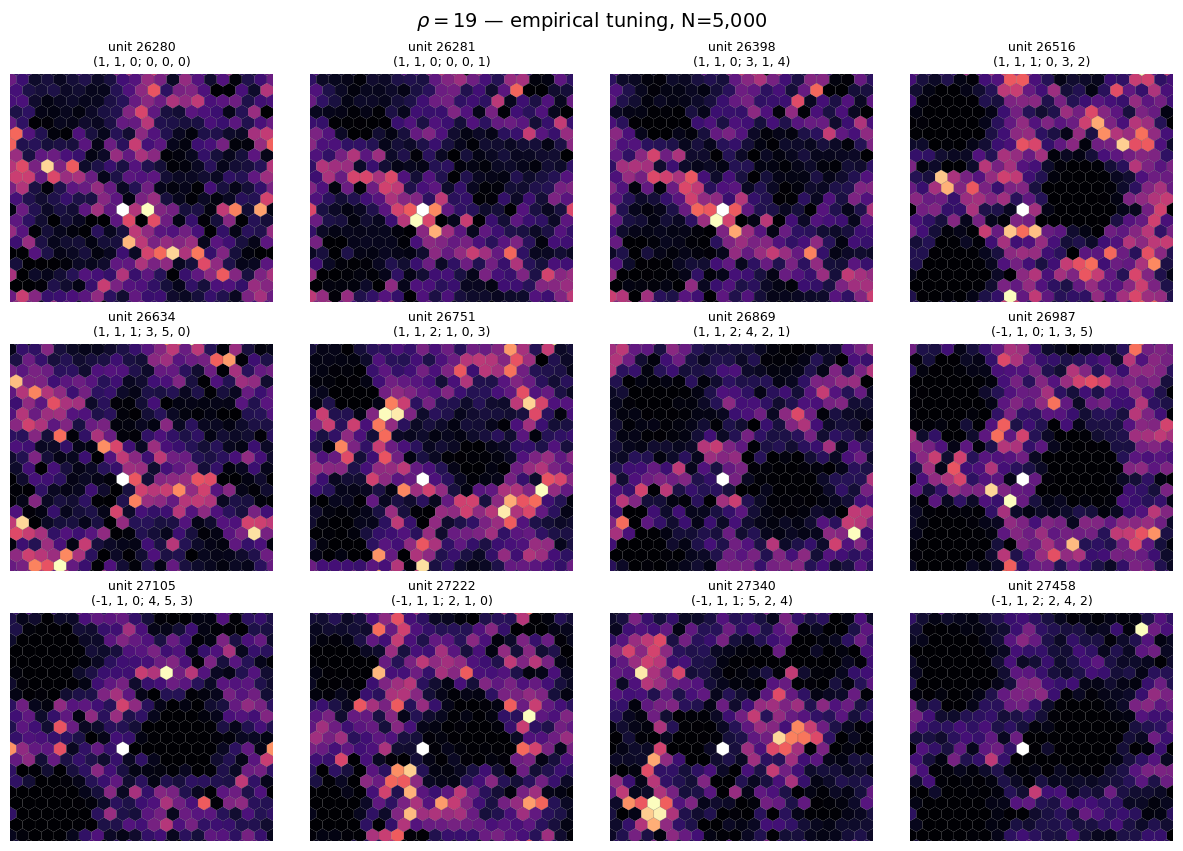

Saved: panelc/empirical_gallery_rho_19_offset_12_N_5000.svg


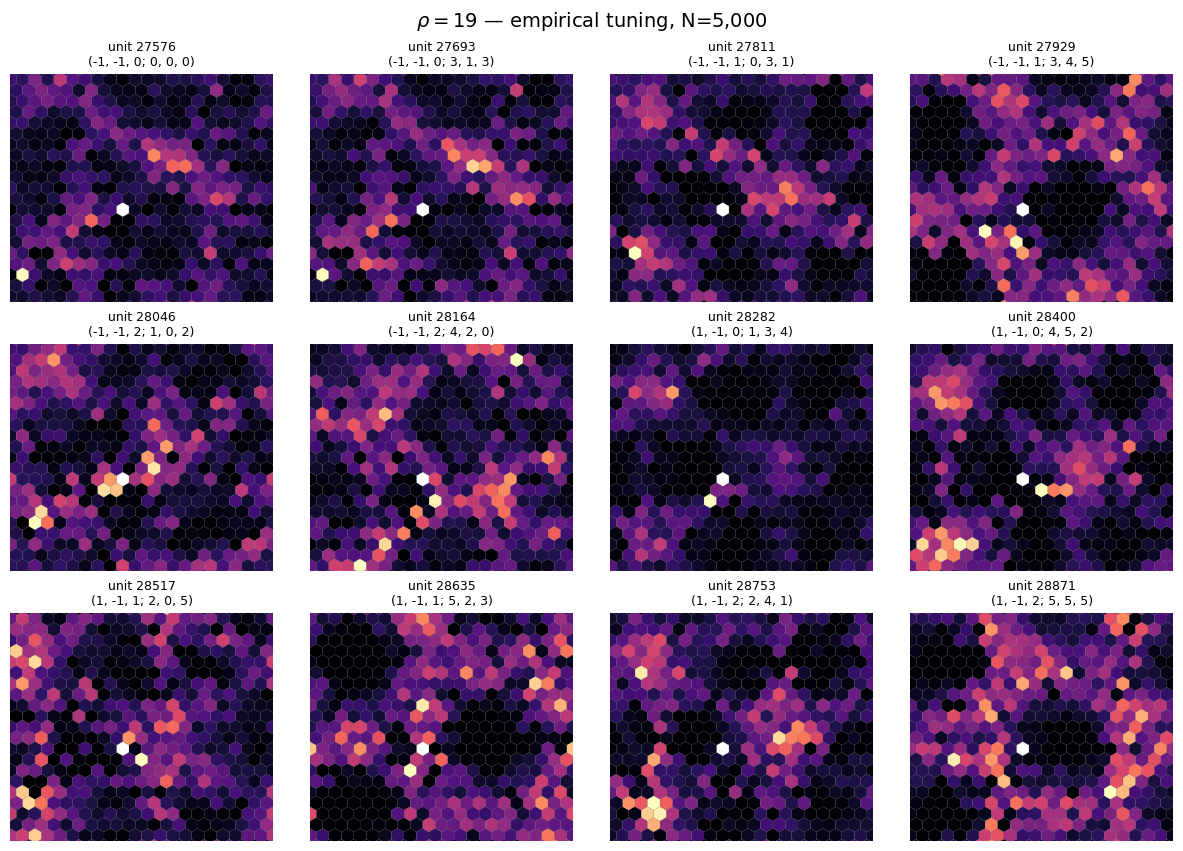

Saved: panelc/empirical_gallery_rho_20_offset_0_N_5000.svg


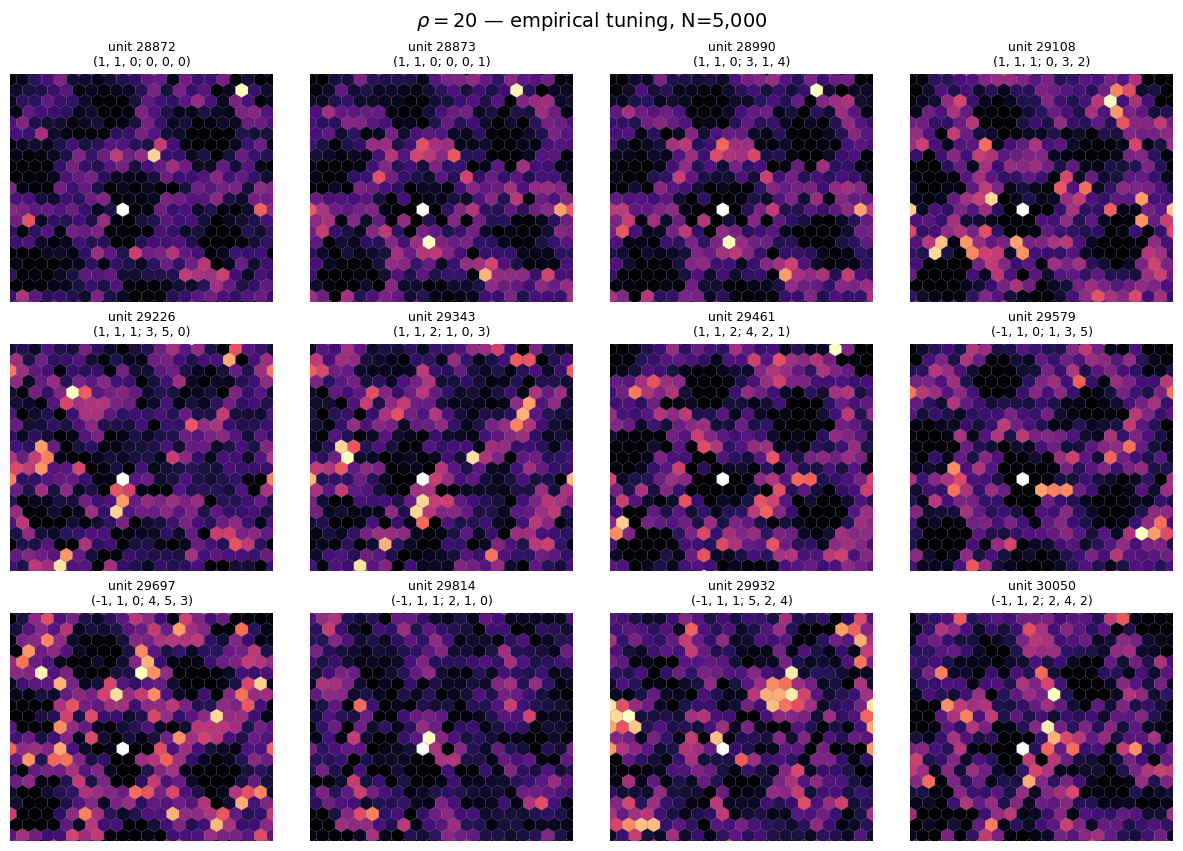

Saved: panelc/empirical_gallery_rho_20_offset_12_N_5000.svg


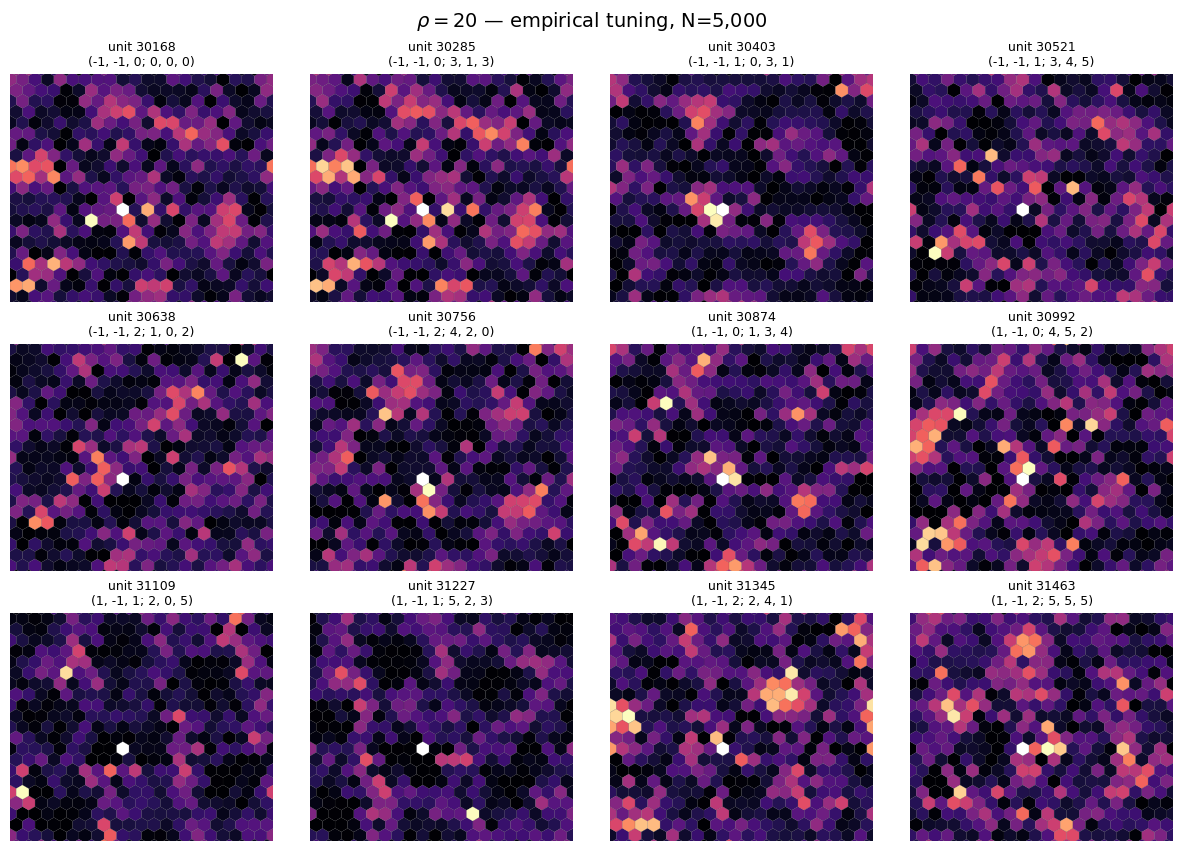

Saved: panelc/empirical_gallery_rho_21_offset_0_N_5000.svg


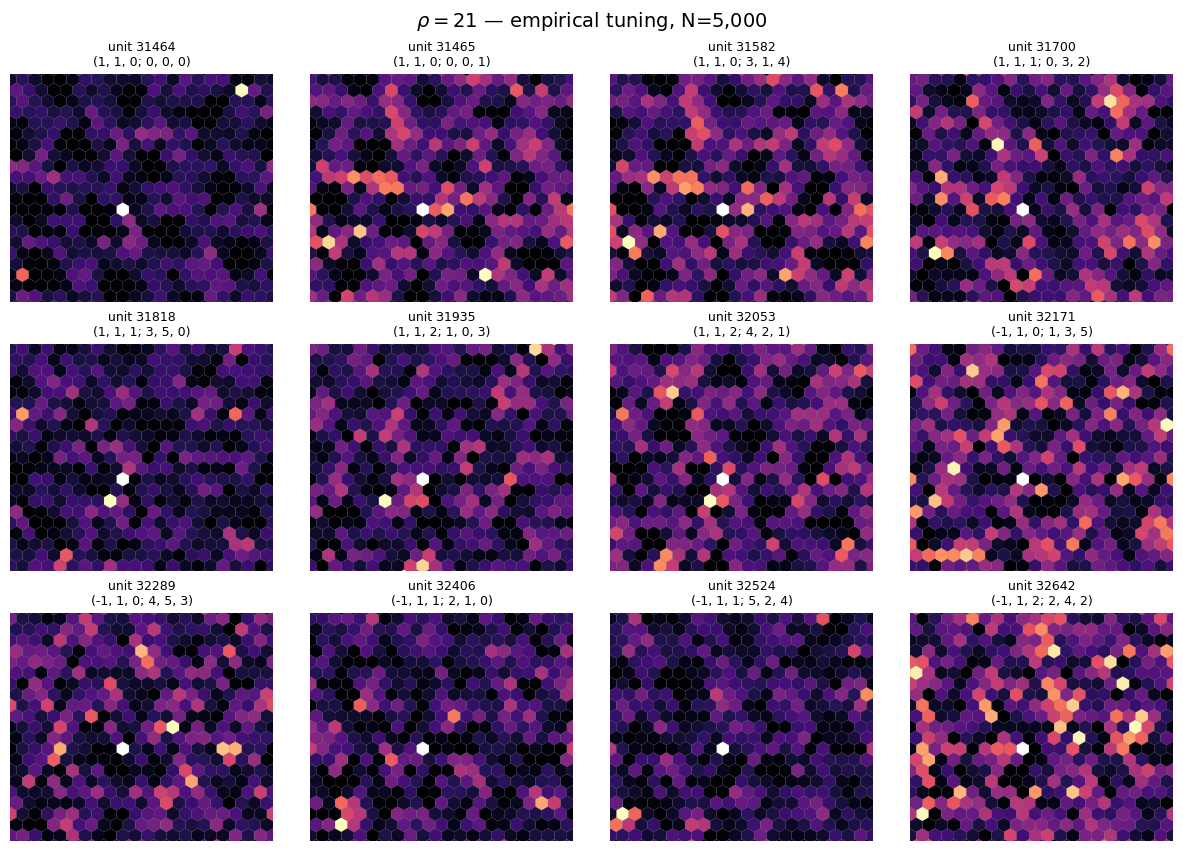

Saved: panelc/empirical_gallery_rho_21_offset_12_N_5000.svg


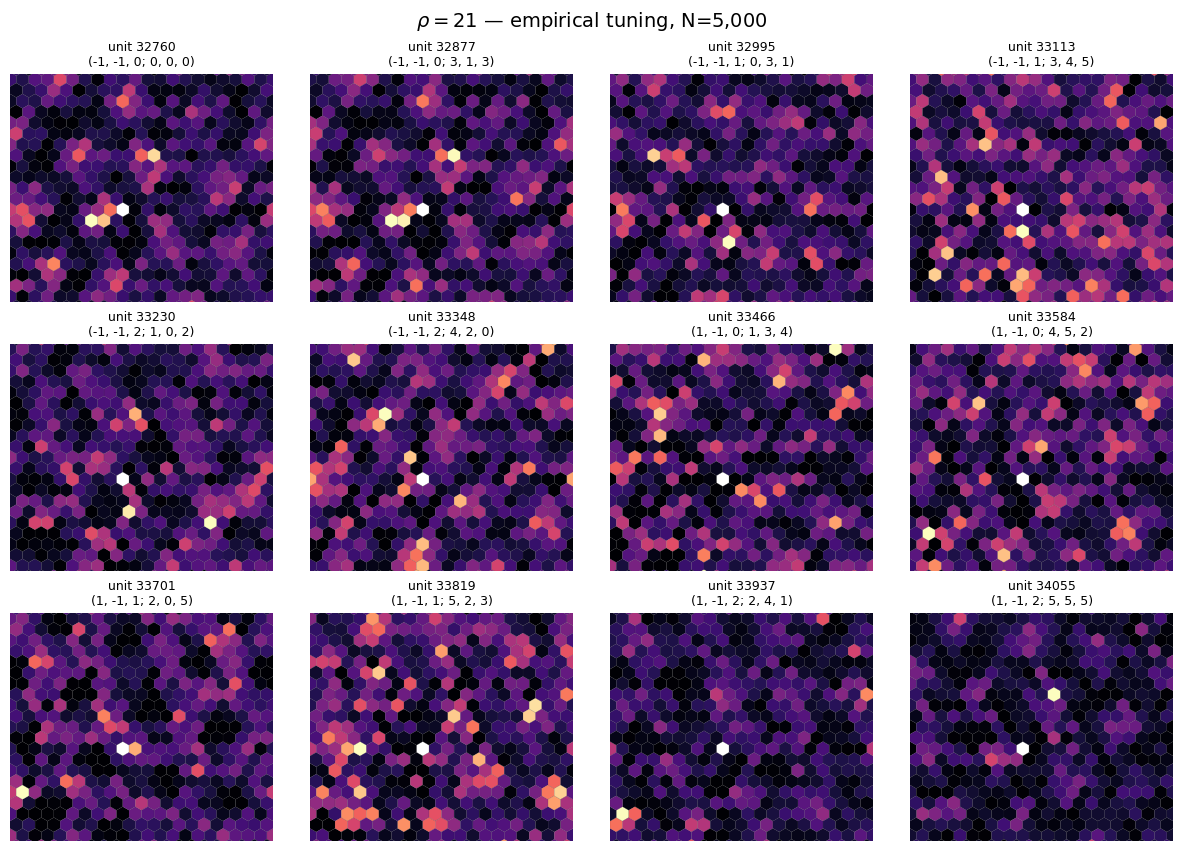

In [11]:
SHOW_EMPIRICAL_GALLERY = True
EXPORT_INDIVIDUAL_EMPIRICAL = False
GALLERY_PAGE_SIZE = 12


def plot_empirical_gallery(data, rho, offset=0, count=12):
    selected = [(j, u) for j, u in enumerate(data['units'])
                if int(experiment.model.metadata[u]['irrep_index']) == rho][offset:offset + count]
    if not selected:
        raise ValueError('No cached units on this gallery page.')
    checkpoint = max(data['counts'])
    columns = min(4, len(selected))
    rows = (len(selected) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(3 * columns, 2.8 * rows), squeeze=False,
                             layout='constrained')
    for axis in axes.flat:
        axis.set_axis_off()
    for axis, (j, unit) in zip(axes.flat, selected):
        labels = experiment.model.metadata[unit]
        plot_lattice_scalar(display_normalized(data['curves'][checkpoint][..., j]), ax=axis,
                            cmap='magma', vmin=0, vmax=1, colorbar=False,
                            coordinate_mode='offset', wrap_periodic_edges=True)
        values = [int(labels[key]) for key in LABEL_NAMES]
        axis.set_title(f'unit {unit}\n({values[0]}, {values[1]}, {values[2]}; '
                       f'{values[3]}, {values[4]}, {values[5]})', fontsize=9)
    fig.suptitle(rf'$\rho={rho}$' + f' — empirical tuning, N={checkpoint:,}', fontsize=14)
    save_panel(fig, 'c', f'empirical_gallery_rho_{rho}_offset_{offset}_N_{checkpoint}')


def export_empirical_maps(data, units=None, checkpoints=None):
    units = data['units'] if units is None else tuple(units)
    checkpoints = (max(data['counts']),) if checkpoints is None else tuple(checkpoints)
    lookup = {u: j for j, u in enumerate(data['units'])}
    for unit in units:
        rho = int(experiment.model.metadata[unit]['irrep_index'])
        for checkpoint in checkpoints:
            fig, axis = plt.subplots(figsize=(4, 4), layout='constrained')
            plot_lattice_scalar(display_normalized(data['curves'][checkpoint][..., lookup[unit]]),
                                ax=axis, cmap='magma', vmin=0, vmax=1, colorbar=False,
                                coordinate_mode='offset', wrap_periodic_edges=True)
            save_panel(fig, 'c', f'empirical_rho_{rho}_neuron_{unit}_N_{checkpoint}', show=False)


if SHOW_EMPIRICAL_GALLERY:
    for gallery_rho in PANEL_C['rhos']:
        count = sum(int(experiment.model.metadata[u]['irrep_index']) == gallery_rho
                    for u in panel_c_data['units'])
        for offset in range(0, count, GALLERY_PAGE_SIZE):
            plot_empirical_gallery(panel_c_data, gallery_rho, offset, GALLERY_PAGE_SIZE)
if EXPORT_INDIVIDUAL_EMPIRICAL:
    export_empirical_maps(panel_c_data)

## Panel D — Translations within a module

Align every neuron's map to the reference by periodic cross-correlation.
Tied maxima select the smallest shift in lattice coordinates. Set
`allow_inversion=True` to also allow contrast reversal. Correlations are reported
because not every map is necessarily an exact translation of the reference.

In [12]:
def best_alignment(reference, curve, allow_inversion=False):
    reference = np.asarray(reference, dtype=float) - np.mean(reference)
    curve = np.asarray(curve, dtype=float) - np.mean(curve)
    denominator = np.linalg.norm(reference) * np.linalg.norm(curve)
    if not np.isfinite(denominator) or denominator == 0:
        return (np.nan, np.nan), np.nan, 0
    correlation = np.fft.ifft2(
        np.fft.fft2(reference) * np.conj(np.fft.fft2(curve))).real / denominator
    scores = np.abs(correlation) if allow_inversion else correlation
    candidates = np.argwhere(np.isclose(scores, scores.max(), atol=1e-12, rtol=0))
    shape = np.asarray(curve.shape)
    shifts = (candidates + shape // 2) % shape - shape // 2
    choice = np.argmin(np.sum(shifts**2, axis=1))
    index = tuple(candidates[choice])
    return tuple(shifts[choice]), float(scores[index]), 1 if correlation[index] >= 0 else -1


def compute_panel_d():
    cfg = PANEL_D.copy()
    units = module_units(cfg['rho'])
    tuning = tuning_cache.get(units, cfg['scope'])
    maps = {int(u): tuning.position_mean[..., j] for j, u in enumerate(tuning.unit_indices)}
    fixed = {key: cfg[key] for key in ('eps1', 'eps2', 'k1', 'k2')}
    reference_unit = unit_with_labels(cfg['rho'], **fixed)
    reference = maps[reference_unit]
    if np.ptp(reference) == 0:
        raise ValueError('Panel D reference is constant; choose another module or reference.')
    results = [best_alignment(reference, maps[u], cfg['allow_inversion']) for u in units]
    shifts = np.asarray([r[0] for r in results])
    scores = np.asarray([r[1] for r in results])
    polarities = np.asarray([r[2] for r in results])
    valid = np.isfinite(scores)
    print(f'Panel D: {valid.sum()}/{len(units)} defined shifts; '
          f'median alignment correlation = {np.median(scores[valid]):.3f}.')
    if cfg['allow_inversion']:
        print(f'Contrast inversion selected for {np.count_nonzero(polarities == -1)} neurons.')
    return dict(cfg=cfg, units=units, maps=maps, shifts=shifts, scores=scores,
                polarities=polarities, reference_unit=reference_unit)


panel_d_data = compute_panel_d()

Panel D: 2592/2592 defined shifts; median alignment correlation = 0.779.


### D. Plot and save

Colored scatter points match the borders of the delta-by-k0 tuning maps.
Coincident shifts overlap; concentric markers keep highlighted colors visible.

Saved: paneld/module_21_local_translation_shifts.svg


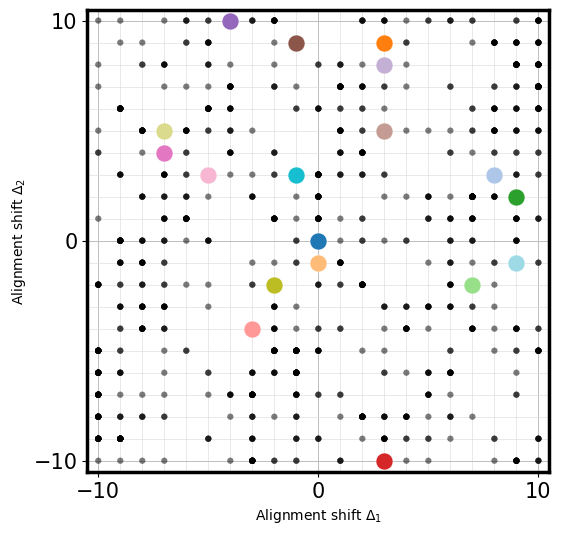

Saved: paneld/module_21_local_delta_k0.svg


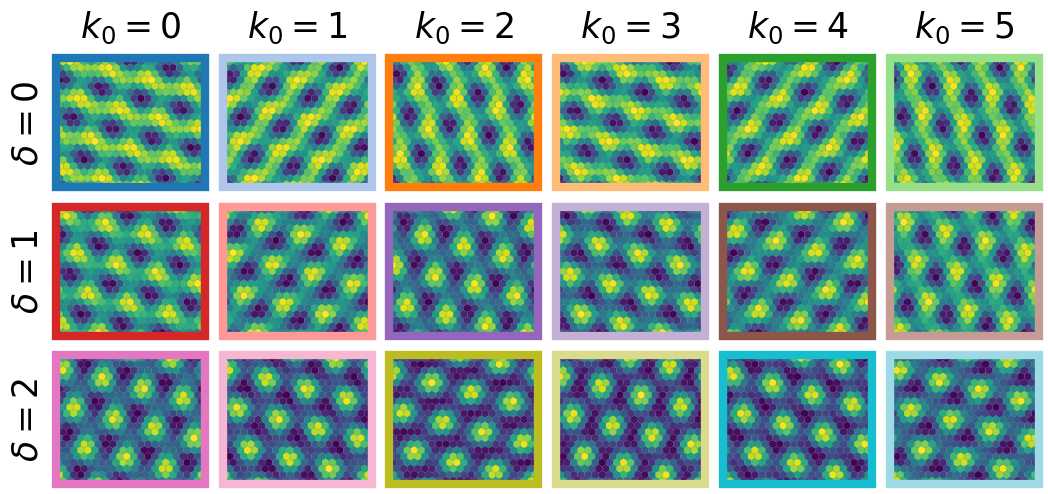

In [13]:
def plot_panel_d(data):
    cfg = data['cfg']
    rho, eps1, eps2, k1, k2 = (cfg[key] for key in ('rho', 'eps1', 'eps2', 'k1', 'k2'))
    nrows, ncols = len(cfg['delta_values']), len(cfg['k0_values'])
    if nrows * ncols > 18:
        raise ValueError('The matching-color palette supports at most 18 highlighted neurons.')
    maps, shifts, scores = data['maps'], data['shifts'], data['scores']
    shift_units = np.asarray(data['units'])
    valid = np.isfinite(scores)
    reference = maps[data['reference_unit']]
    # One color for each of the 18 displayed neurons.
    palette = [
        color for i, color in enumerate(plt.get_cmap("tab20").colors)
        if i not in (14, 15)  # Omit the two gray colors.
    ]
    highlight_colors = {
        unit_with_labels(rho, eps1=eps1, eps2=eps2, delta=delta, k0=k0, k1=k1, k2=k2): palette[row * ncols + col]
        for row, delta in enumerate(cfg['delta_values'])
        for col, k0 in enumerate(cfg['k0_values'])
    }
    shift_index = {int(unit): index for index, unit in enumerate(shift_units)}


    # Figure 1: black background points and larger colored highlights.
    figure, axis = plt.subplots(figsize=(5.5, 5.5), constrained_layout=True)

    background = valid & ~np.isin(shift_units, list(highlight_colors))
    axis.scatter(
        shifts[background, 0], shifts[background, 1],
        color="black", s=20, alpha=0.3, edgecolors="none",
    )

    # Group coincident highlights so every color remains visible.
    highlight_groups = {}
    for unit, color in highlight_colors.items():
        index = shift_index[unit]
        if valid[index]:
            position = tuple(shifts[index])
            highlight_groups.setdefault(position, []).append(color)

    for position, colors in highlight_groups.items():
        for j, color in enumerate(colors):
            axis.scatter(
                *position,
                s=150 + 80 * (len(colors) - j - 1),
                color=color,
                edgecolors="white",
                linewidths=0.4,
                zorder=3 + j,
            )

    axis.axhline(0, color="0.8", linewidth=0.6, zorder=0)
    axis.axvline(0, color="0.8", linewidth=0.6, zorder=0)

    size = reference.shape[0]
    lags = np.arange(size) - size // 2
    limits = (lags[0] - 0.5, lags[-1] + 0.5)
    axis.set(xlim=limits, ylim=limits, aspect="equal",
             xlabel=r"Alignment shift $\Delta_1$", ylabel=r"Alignment shift $\Delta_2$")

    ticks = np.linspace(lags[0], lags[-1], 3)
    axis.set_xticks(ticks)
    axis.set_yticks(ticks)
    axis.tick_params(axis="both", labelsize=15)

    axis.set_axisbelow(True)
    axis.xaxis.set_minor_locator(MultipleLocator(1))
    axis.yaxis.set_minor_locator(MultipleLocator(1))

    axis.grid(which="major", color="0.75", linewidth=0.7)
    axis.grid(which="minor", color="0.88", linewidth=0.5)
    axis.tick_params(which="minor", bottom=False, left=False)

    for spine in axis.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color("black")

    save_panel(figure, 'd', f'module_{rho}_{cfg["scope"]}_translation_shifts')


    # Figure 2: tuning maps with matching colored borders.
    figure, axes = plt.subplots(
        nrows, ncols, figsize=(10.8, 5.1), squeeze=False, layout="none",
    )
    row_gap, column_gap = 0.15, 0.12
    figure.subplots_adjust(
        left=0.08, right=0.99, bottom=0.03, top=0.88,
        wspace=column_gap, hspace=row_gap,
    )

    for row, delta in enumerate(cfg['delta_values']):
        for col, k0 in enumerate(cfg['k0_values']):
            axis = axes[row, col]
            unit = unit_with_labels(rho, eps1=eps1, eps2=eps2, delta=delta, k0=k0, k1=k1, k2=k2)

            plot_lattice_scalar(
                display_normalized(maps[unit]),
                ax=axis, cmap="viridis", vmin=0, vmax=1,
                colorbar=False, coordinate_mode="offset",
                wrap_periodic_edges=True,
            )

            # A patch remains visible even though the lattice helper hides axes.
            axis.add_patch(Rectangle(
                (0, 0), 1, 1,
                transform=axis.transAxes,
                fill=False,
                edgecolor=highlight_colors[unit],
                linewidth=6,
                clip_on=False,
                zorder=10,
            ))

            if row == 0:
                axis.set_title(rf"$k_0={k0}$", fontsize=25, pad=15)
            if col == 0:
                axis.annotate(
                    rf"$\delta={delta}$", (-0.08, 0.5),
                    xycoords="axes fraction",
                    ha="right", va="center", fontsize=25,
                    rotation=90,
                )

    p = figure.subplotpars
    figure.set_figheight(
        figure.get_figwidth()
        * (p.right - p.left) / (p.top - p.bottom)
        * (nrows + (nrows - 1) * row_gap) / (ncols + (ncols - 1) * column_gap)
        * axes[0, 0].get_data_ratio()
    )

    save_panel(figure, 'd', f'module_{rho}_{cfg["scope"]}_delta_k0')

plot_panel_d(panel_d_data)

## Panel E — Tuning classes

Classify the configured neuron subset using modulation
$(\max f-\min f)/\max(\max|f|,10^{-12})$ and threshold 0.01.
Spatial and heading modulation above threshold gives “Conjunctive”.
One above threshold gives the corresponding single-variable class.

In [14]:
def modulation(values):
    values = np.asarray(values)
    return float(np.ptp(values) / max(np.max(np.abs(values)), 1e-12))


def classify_tuning(tuning, threshold=1e-2):
    records = []
    for column, unit in enumerate(tuning.unit_indices):
        mx = modulation(tuning.position_mean[..., column])
        mtheta = modulation(tuning.heading_mean[:, column])
        if mx > threshold and mtheta > threshold:
            category = 'Conjunctive'
        elif mx > threshold:
            category = 'Spatial only'
        elif mtheta > threshold:
            category = 'Orientation only'
        else:
            category = 'Untuned'
        records.append(dict(unit=int(unit), column=column,
                            rho=int(experiment.model.metadata[int(unit)]['irrep_index']),
                            mx=mx, mtheta=mtheta,
                            heading=int(np.argmax(tuning.heading_mean[:, column])), category=category))
    return records


panel_e_tuning = tuning_cache.get(panel_e_units(), PANEL_E['scope'])
panel_e_records = classify_tuning(panel_e_tuning, PANEL_E['threshold'])
print(f'Classified {len(panel_e_records):,} actual neurons with {PANEL_E["scope"]} tuning; '
      f'label filter = {PANEL_E["unit_filter"]}.')

Classified 7,938 actual neurons with local tuning; label filter = {'eps1': 1, 'eps2': 1, 'k1': 0}.


### E. Examples

Search the allowed modules for one neuron per class. Pizza plots have different
colors and share one raw-activity deviation scale. The dashed radius marks the
mean. A row reports if no qualifying neuron exists.

Spatial only: rho=46, neuron 96519 (67 candidates).
Conjunctive: rho=19, neuron 26786 (216 candidates).
Orientation only: rho=1, neuron 12 (6 candidates).
Saved: panele/position_heading_examples_local.svg


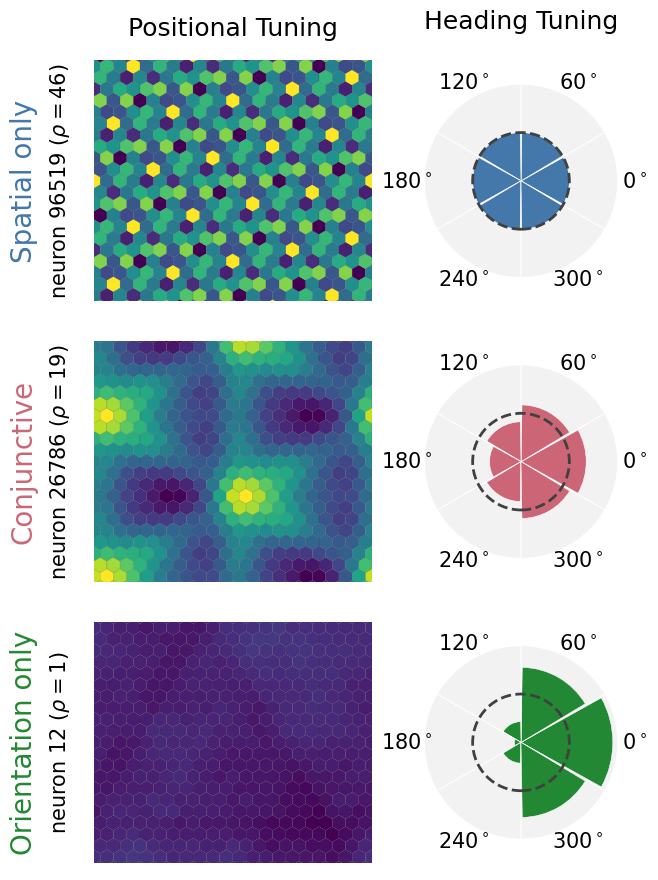

In [15]:
def plot_panel_e(tuning, records):
    classes = CLASSES
    example_rhos = PANEL_E['example_rhos']
    pizza_colors = PIZZA_COLORS
    heading_curves = tuning.heading_mean
    examples = []
    for category in classes:
        allowed_rhos = example_rhos[category]
        candidates = [
            r for r in records
            if r["category"] == category
            and (allowed_rhos is None or r["rho"] in allowed_rhos)
        ]

        def score(record):
            if category == "Conjunctive":
                return min(record["mx"], record["mtheta"])
            return record["mx"] if category == "Spatial only" else record["mtheta"]

        selected = max(candidates, key=score) if candidates else None
        examples.append(selected)

        if selected is None:
            print(f"{category}: no matching neurons for rho={allowed_rhos}.")
        else:
            print(
                f"{category}: rho={selected['rho']}, "
                f"neuron {selected['unit']} "
                f"({len(candidates)} candidates)."
            )

    heading_deviation_scale = max(
        (
            np.max(np.abs(
                heading_curves[:, r["column"]]
                - heading_curves[:, r["column"]].mean()
            ))
            for r in examples if r is not None
        ),
        default=0,
    )
    heading_deviation_scale = max(heading_deviation_scale, 1e-12)

    widths = (1.2, 1.1)
    column_gap, row_gap = 0.08, 0.10

    figure, axes = plt.subplots(
        3, 2, figsize=(7.5, 7),
        gridspec_kw={"width_ratios": widths},
        layout="none",
    )
    figure.subplots_adjust(
        left=0.22, right=0.96, bottom=0.04, top=0.96,
        wspace=column_gap, hspace=row_gap,
    )

    for row, (category, record) in enumerate(zip(classes, examples)):
        axes[row, 0].annotate(
            category, (-0.25, 0.5),
            xycoords="axes fraction", rotation=90,
            ha="center", va="center", fontsize=20, color=pizza_colors[category],
        )

        if record is None:
            allowed_rhos = example_rhos[category]
            message = "No matching neurons"
            if allowed_rhos is not None:
                message += "\n" + r"$\rho \in \{" + ", ".join(
                    str(rho) for rho in allowed_rhos
                ) + r"\}$"

            axes[row, 0].text(
                0.5, 0.5, message,
                transform=axes[row, 0].transAxes,
                ha="center", va="center",
            )
            for axis in axes[row]:
                axis.set_axis_off()
            continue

        column = record["column"]

        plot_lattice_scalar(
            display_normalized(tuning.position_mean[..., column]),
            ax=axes[row, 0], cmap="viridis", vmin=0, vmax=1,
            colorbar=False, coordinate_mode="offset",
            wrap_periodic_edges=True,
        )
        axes[row, 0].annotate(
             rf"neuron {record['unit']} " + rf"$(\rho={record['rho']})$",
            (-0.12, 0.5),
            xycoords="axes fraction", rotation=90,
            ha="center", va="center", fontsize=15,
        )

        plot_orientation_pizza(
            heading_curves[:, column],
            axes[row, 1], pizza_colors[category], heading_deviation_scale,
        )

        axes[row, 1].tick_params(axis="both", labelsize=11)
        for text in axes[row, 1].texts:
            text.set_fontsize(15)

    # Fit row height to the plots.
    row_height = max(
        widths[col] * axes[row, col].get_data_ratio()
        for row, record in enumerate(examples) if record is not None
        for col in range(2)
    ) if any(record is not None for record in examples) else 1

    p = figure.subplotpars
    figure.set_figheight(
        figure.get_figwidth()
        * (p.right - p.left) / (p.top - p.bottom)
        * (3 + 2 * row_gap) * row_height
        / (sum(widths) * (1 + column_gap / 2))
    )

    axes[0, 0].set_title("Positional Tuning", fontsize=18, pad=18)
    axes[0, 1].set_title("Heading Tuning", fontsize=18, pad=18)

    save_panel(figure, 'e', f'position_heading_examples_{tuning.scope}')
    return examples

selected_e_examples = plot_panel_e(panel_e_tuning, panel_e_records)

### E. Counts by module

Count the actual classified subset, with no multiplicity extrapolation. Set
`unit_filter={}` to classify all neurons. Save the histogram and a cached CSV table.

category,Spatial only,Conjunctive,Orientation only,Untuned,Total
rho,,,,,
0,0,0,0,3,3
1,0,0,3,0,3
2,0,0,0,3,3
3,0,0,0,3,3
4,0,0,0,3,3
...,...,...,...,...,...
77,0,0,0,108,108
78,1,0,0,107,108
79,8,0,0,100,108


Saved: panele/class_counts_local.svg


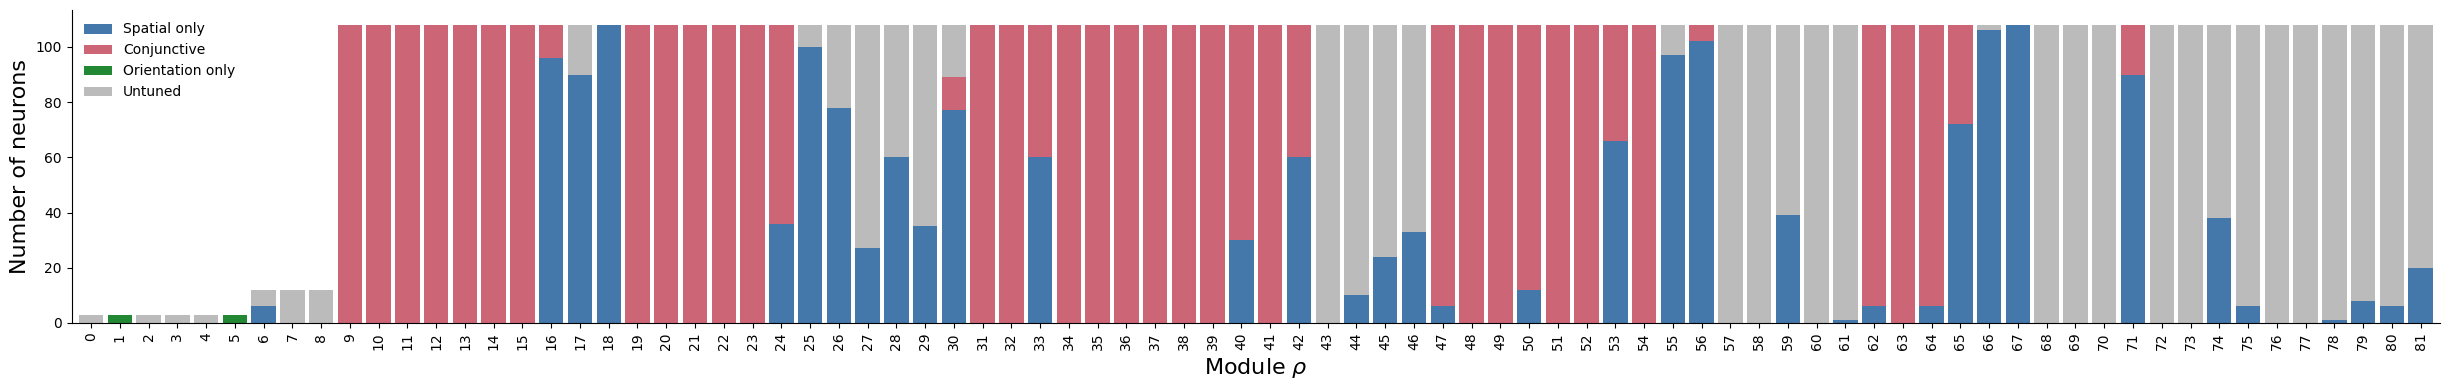

In [16]:
categories = [
    "Spatial only", "Conjunctive", "Orientation only", "Untuned"
]
colors = ["#4477AA", "#CC6677", "#228833", "#BBBBBB"]

df = pd.DataFrame(panel_e_records)
counts = pd.crosstab(df["rho"], df["category"]).reindex(
    columns=categories, fill_value=0
).sort_index()

table = counts.copy()
table["Total"] = table.sum(axis=1)
display(table)
table.to_csv(model_cache_dir / f'class_counts_{panel_e_tuning.scope}.csv')

axis = counts.plot.bar(
    stacked=True,
    color=colors,
    figsize=(max(8, 0.3 * len(counts)), 4),
    width=0.85,
)
axis.set_xlabel(r"Module $\rho$", fontsize=16)
axis.set_ylabel("Number of neurons", fontsize=16)
axis.legend(title="", frameon=False)
axis.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save_panel(axis.figure, 'e', f'class_counts_{panel_e_tuning.scope}')

## Panel F — Population geometry

Use the supplied pipeline: compute all neurons of one module in batches of 256
with 32 drives per batch, center each neuron, and apply one shared RMS scale.
Choose UMAP, 3D PCA, or 9D PCA followed by UMAP. The PCA branches standardize
nonconstant neurons first. Persistent homology always uses full-population
distances, independently of the visualization.

Population data, embedding coordinates, and persistence diagrams are saved
separately in `figure6/cache/<model>/`. Camera changes reuse the saved embedding.
UMAP's appearance can depend on library versions even with a fixed seed.

In [ ]:
def compute_panel_f():
    cfg = PANEL_F.copy()
    rho, method = cfg['rho'], cfg['embedding_method']
    if method not in {'umap', 'pca', 'pca_umap'}:
        raise ValueError('Choose umap, pca, or pca_umap.')
    units = module_units(rho)
    drives = (tuple(experiment.local_egocentric_elements) if cfg['scope'] == 'local'
              else tuple(experiment.group.elements()) if cfg['scope'] == 'global' else None)
    if drives is None:
        raise ValueError('Choose local or global drives.')

    base = dict(rho=rho, scope=cfg['scope'], units=units,
                unit_batch_size=cfg['unit_batch_size'], drive_batch_size=cfg['drive_batch_size'])
    population_path = model_cache_dir / f'population_rho_{rho}_{cfg["scope"]}_{fingerprint(base)}.npz'
    if USE_DISK_CACHE and population_path.exists():
        with np.load(population_path, allow_pickle=False) as stored:
            population, distances = stored['population'], stored['distances']
        print(f'Loaded population data: {population_path.name}')
    else:
        # Preserve the original unit order, batching, concatenation, and normalization.
        started = time.perf_counter()
        population_blocks = []
        for first in range(0, len(units), cfg['unit_batch_size']):
            tuning = compute_one_step_tuning(
                experiment, units[first:first + cfg['unit_batch_size']], drives,
                drive_batch_size=cfg['drive_batch_size'],
            )
            population_blocks.append(tuning.position_mean.reshape(-1, len(tuning.unit_indices)))
        population = np.concatenate(population_blocks, axis=1).astype(float)
        del population_blocks
        if not np.isfinite(population).all():
            raise ValueError('Population activity contains nonfinite values.')
        population -= population.mean(axis=0, keepdims=True)
        scale = np.sqrt(np.mean(np.sum(population**2, axis=1)))
        if scale <= 0:
            raise ValueError('The population has no spatial variation.')
        population /= scale
        distances = squareform(pdist(population, metric='euclidean'))
        if USE_DISK_CACHE:
            write_npz(population_path, population=population, distances=distances, unit_indices=units)
        print(f'rho={rho}: {population.shape[0]} positions, {population.shape[1]} neurons; '
              f'tuning computed in {time.perf_counter() - started:.1f} s.')

    viz_key = fingerprint(dict(base, **{key: cfg[key] for key in (
        'embedding_method', 'pca_dimensions', 'umap_neighbors', 'umap_min_dist', 'random_seed')}))
    viz_path = model_cache_dir / f'embedding_rho_{rho}_{method}_{viz_key}.npz'
    if USE_DISK_CACHE and viz_path.exists():
        with np.load(viz_path, allow_pickle=False) as stored:
            embedding, explained_variance = stored['embedding'], stored['explained_variance']
        print(f'Loaded {method} embedding.')
    else:
        pca = None
        population_pca = None
        explained_variance = np.array([])
        if method in {'pca', 'pca_umap'}:
            neuron_std = population.std(axis=0)
            varying = neuron_std > max(1e-12, neuron_std.max() * 1e-8)
            components = 3 if method == 'pca' else cfg['pca_dimensions']
            if components < 3 or components > min(len(population) - 1, int(varying.sum())):
                raise ValueError('Use at least three PCs, within the available positions and varying neurons.')
            standardized_population = StandardScaler().fit_transform(population[:, varying])
            pca = PCA(n_components=components, svd_solver='full', whiten=False)
            population_pca = pca.fit_transform(standardized_population)
            explained_variance = pca.explained_variance_ratio_
        if method == 'pca':
            embedding = population_pca[:, :3].copy()
        else:
            use_pca = method == 'pca_umap'
            embedding = UMAP(
                n_components=3,
                n_neighbors=min(cfg['umap_neighbors'], len(population) - 1),
                min_dist=cfg['umap_min_dist'],
                metric='euclidean' if use_pca else 'precomputed',
                random_state=cfg['random_seed'],
            ).fit_transform(population_pca if use_pca else distances)
        if USE_DISK_CACHE:
            write_npz(viz_path, embedding=embedding, explained_variance=explained_variance)
    if explained_variance.size:
        print(f'{len(explained_variance)} PCs explain {100 * explained_variance.sum():.2f}% of standardized variance.')

    landmarks = len(population) if cfg['ph_max_points'] is None else min(int(cfg['ph_max_points']), len(population))
    if landmarks < 4:
        raise ValueError('Use at least four position landmarks.')
    ph_path = model_cache_dir / f'persistence_rho_{rho}_{fingerprint(dict(base, landmarks=landmarks))}.npz'
    if USE_DISK_CACHE and ph_path.exists():
        with np.load(ph_path, allow_pickle=False) as stored:
            diagrams = [stored[f'H{d}'] for d in range(3)]
            landmark_indices = stored['landmark_indices']
        print('Loaded persistent homology.')
    else:
        print(f'Computing persistent homology through H2 with {landmarks} positions...')
        ph = ripser(distances, distance_matrix=True, maxdim=2, coeff=2, n_perm=landmarks)
        diagrams, landmark_indices = ph['dgms'], ph['idx_perm']
        if USE_DISK_CACHE:
            write_npz(ph_path, **{f'H{d}': diagram for d, diagram in enumerate(diagrams)},
                      landmark_indices=landmark_indices)
    return dict(cfg=cfg, units=units, population=population, distances=distances, embedding=embedding,
                diagrams=diagrams, landmark_indices=landmark_indices,
                explained_variance=explained_variance)


panel_f_data = compute_panel_f()

### F. Static figures

Save the surface, reference tuning map, and persistence barcodes. Colors, mesh,
camera, and bar opacity follow the supplied plot. Change `elevation` and `azimuth`
to rotate; disable `surface` and `wireframe` for points only.

Mesh edges come from arena adjacency. The highlighted 1/2/1 bars are a display
choice, not a topology test; homology is computed independently of this mesh.

Coloring rho=9 with reference neuron 360.
Saved: panelf/module_9_global_umap_population.svg


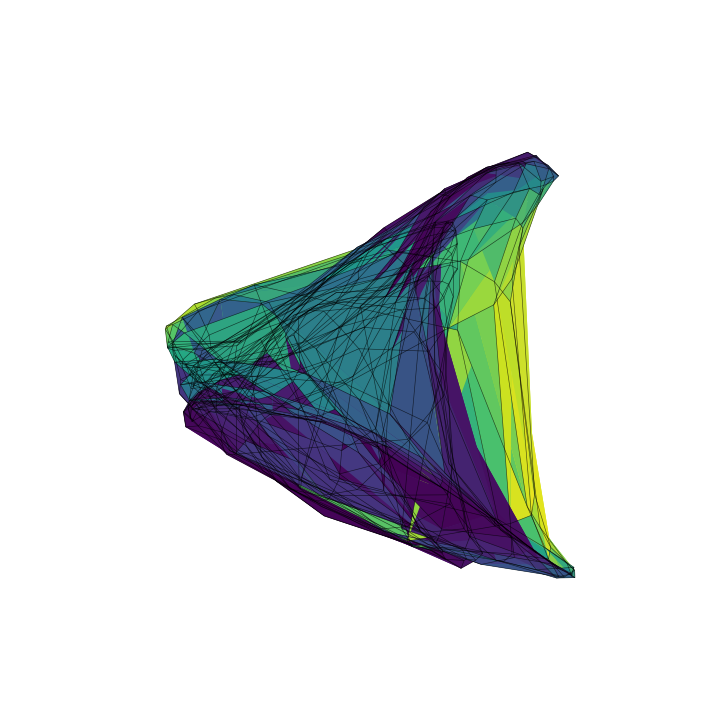

Saved: panelf/module_9_global_reference_tuning.svg


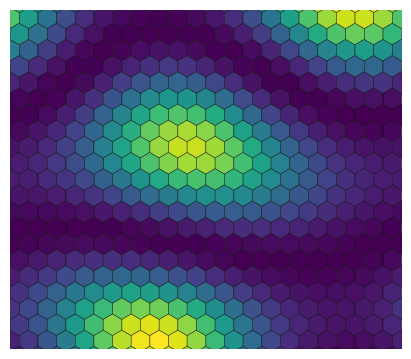

Saved: panelf/module_9_global_persistence.svg


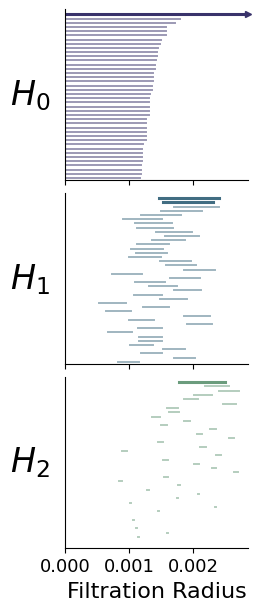

In [21]:
def population_plot_geometry(data):
    size = experiment.group.n
    reference_unit = unit_with_labels(data['cfg']['rho'])
    reference_column = data['units'].index(reference_unit)
    embedding = data['embedding']
    if embedding.shape != (size * size, 3):
        raise ValueError('Expected one 3D embedded point per spatial bin.')
    reference_map = display_normalized(data['population'][:, reference_column].reshape(size, size))
    index_grid = np.arange(size * size).reshape(size, size)
    triangles, edges = [], []
    for i in range(size):
        for j in range(size):
            a = index_grid[i, j]
            b = index_grid[(i + 1) % size, j]
            c = index_grid[(i + 1) % size, (j + 1) % size]
            d = index_grid[i, (j + 1) % size]
            triangles.extend(((a, b, c), (a, c, d)))
            edges.extend(((a, b), (a, d)))
    return dict(reference_unit=reference_unit, reference_map=reference_map,
                triangles=np.asarray(triangles), edges=np.asarray(edges))


def plot_panel_f(data):
    cfg = data['cfg']
    rho = cfg['rho']
    embedding, diagrams = data['embedding'], data['diagrams']
    geometry = population_plot_geometry(data)
    triangles, edges = geometry['triangles'], geometry['edges']
    reference_map = geometry['reference_map']
    position_colors = plt.colormaps['viridis'](reference_map.ravel())[:, :3]
    name = f'module_{rho}_{cfg["scope"]}'
    print(f'Coloring rho={rho} with reference neuron {geometry["reference_unit"]}.')

    figure = plt.figure(figsize=(7, 7), layout='none')
    axis = figure.add_axes((0, 0, 1, 1), projection='3d')
    if PANEL_F['surface']:
        axis.add_collection3d(Poly3DCollection(
            embedding[triangles], facecolors=position_colors[triangles].mean(axis=1),
            edgecolors='none', alpha=1))
    else:
        axis.scatter(*embedding.T, c=position_colors, s=24, edgecolors='none', depthshade=False)
    if PANEL_F['wireframe']:
        axis.add_collection3d(Line3DCollection(
            embedding[edges], colors='black', linewidths=0.45, alpha=0.65))
    center = (embedding.max(axis=0) + embedding.min(axis=0)) / 2
    radius = max(np.ptp(embedding, axis=0).max() / 2, 1e-12) * 1.05
    axis.set(xlim=(center[0] - radius, center[0] + radius),
             ylim=(center[1] - radius, center[1] + radius),
             zlim=(center[2] - radius, center[2] + radius))
    axis.set_box_aspect((1, 1, 1), zoom=1.15)
    axis.set_proj_type('ortho')
    axis.view_init(elev=PANEL_F['elevation'], azim=PANEL_F['azimuth'])
    axis.set_axis_off()
    save_panel(figure, 'f', f'{name}_{cfg["embedding_method"]}_population')

    figure, axis = plt.subplots(figsize=(4, 4), layout='constrained')
    plot_lattice_scalar(reference_map, ax=axis, cmap='viridis', vmin=0, vmax=1,
                        colorbar=False, coordinate_mode='offset', wrap_periodic_edges=True)
    axis.collections[-1].set(edgecolor=(0, 0, 0, 0.65), linewidth=0.45)
    save_panel(figure, 'f', f'{name}_reference_tuning')

    finite_deaths = np.concatenate([d[np.isfinite(d[:, 1]), 1] for d in diagrams])
    right_edge = max(1.05 * finite_deaths.max(), 1e-12) if finite_deaths.size else 1
    colors = ('#39336B', '#416D82', '#6B9C7D')
    highlight_counts = (1, 2, 1)
    figure, axes = plt.subplots(3, 1, figsize=(2.5, 6), sharex=True, layout='constrained')
    for dimension, (axis, diagram, color) in enumerate(zip(axes, diagrams, colors)):
        order = np.argsort(diagram[:, 1] - diagram[:, 0])[::-1][:PANEL_F['max_bars']]
        for row, index in enumerate(order):
            birth, death = diagram[index]
            end = death if np.isfinite(death) else right_edge
            highlighted = row < highlight_counts[dimension]
            alpha = 1.0 if highlighted else PANEL_F['background_alpha']
            axis.plot([birth, end], [row, row], color=color,
                      linewidth=2.2 if highlighted else 1.4, alpha=alpha)
            if not np.isfinite(death):
                axis.plot(end, row, marker='>', markersize=5, color=color, alpha=alpha, clip_on=False)
        count = max(len(order), 1)
        axis.set(xlim=(0, right_edge), ylim=(count - 0.5, -max(0.5, 0.03 * count)), yticks=[])
        axis.set_ylabel(rf'$H_{dimension}$', rotation=0, fontsize=24, labelpad=25, va='center')
        axis.spines[['top', 'right']].set_visible(False)
        axis.tick_params(labelsize=13)
    axes[-1].set_xlabel('Filtration Radius', fontsize=16)
    save_panel(figure, 'f', f'{name}_persistence')


plot_panel_f(panel_f_data)

### F. Interactive camera (optional)

Set `RUN_INTERACTIVE=True` to save a standalone HTML viewer. Its live elevation
and azimuth readout can be copied into `PANEL_F` for the static plot.

In [24]:
def show_population_viewer(data):
    import plotly.graph_objects as go
    embedding = data['embedding']
    rho = data['cfg']['rho']
    geometry = population_plot_geometry(data)
    triangles, edges = geometry['triangles'], geometry['edges']
    reference_unit = geometry['reference_unit']
    point_activity = geometry['reference_map'].ravel()
    point_rgb = plt.colormaps['viridis'](point_activity)[:, :3]
    coordinates = np.indices((n, n)).reshape(2, -1)
    elevation, azimuth = PANEL_F['elevation'], PANEL_F['azimuth']
    def rgb_strings(colors):
        return [
            f"rgb({r},{g},{b})"
            for r, g, b in np.round(
                np.clip(colors, 0, 1) * 255
            ).astype(int)
        ]


    # Interactive population view.
    combined_figure = go.Figure()

    combined_figure.add_trace(go.Scatter3d(
        x=embedding[:, 0],
        y=embedding[:, 1],
        z=embedding[:, 2],
        mode="markers",
        marker=dict(
            size=4,
            color=point_activity,
            colorscale="Viridis",
            cmin=0, cmax=1,
            opacity=1,
            line=dict(width=0),
            colorbar=dict(title="Normalized<br>tuning activity"),
        ),
        customdata=np.column_stack((coordinates.T, point_activity)),
        hovertemplate=(
            "Position: (%{customdata[0]}, %{customdata[1]})"
            "<br>Tuning activity: %{customdata[2]:.3f}"
            "<extra></extra>"
        ),
        name="Population vectors",
        showlegend=True,
    ))

    # Match Cell 2's flat triangle colors.
    combined_figure.add_trace(go.Mesh3d(
        x=embedding[:, 0],
        y=embedding[:, 1],
        z=embedding[:, 2],
        i=triangles[:, 0],
        j=triangles[:, 1],
        k=triangles[:, 2],
        facecolor=rgb_strings(point_rgb[triangles].mean(axis=1)),
        opacity=1,
        lighting=dict(
            ambient=1, diffuse=0, specular=0, fresnel=0,
        ),
        hoverinfo="skip",
        name="Tuning-colored surface",
        showlegend=True,
        visible="legendonly",
    ))

    edge_coordinates = np.full((len(edges), 3, 3), np.nan)
    edge_coordinates[:, :2, :] = embedding[edges]
    edge_coordinates = edge_coordinates.reshape(-1, 3)

    combined_figure.add_trace(go.Scatter3d(
        x=edge_coordinates[:, 0],
        y=edge_coordinates[:, 1],
        z=edge_coordinates[:, 2],
        mode="lines",
        line=dict(color="black", width=2),
        opacity=0.65,
        hoverinfo="skip",
        name="Wireframe",
        visible="legendonly",
    ))

    # Equal coordinate scaling, matching the static plot.
    center = (embedding.max(axis=0) + embedding.min(axis=0)) / 2
    radius = max(np.ptp(embedding, axis=0).max() / 2, 1e-12) * 1.05

    elev_rad, azim_rad = np.deg2rad([elevation, azimuth])
    camera_distance = 1.8

    combined_figure.update_layout(
        title=f"Module {rho} — colored by neuron {reference_unit}",
        height=720,
        autosize=True,
        margin=dict(l=0, r=0, b=60, t=50),
        paper_bgcolor="white",
        showlegend=True,
        legend=dict(orientation="h", x=0, y=-0.02),
        scene=dict(
            xaxis=dict(
                visible=False,
                range=[center[0] - radius, center[0] + radius],
            ),
            yaxis=dict(
                visible=False,
                range=[center[1] - radius, center[1] + radius],
            ),
            zaxis=dict(
                visible=False,
                range=[center[2] - radius, center[2] + radius],
            ),
            aspectmode="cube",
            dragmode="turntable",
            camera=dict(
                eye=dict(
                    x=camera_distance * np.cos(elev_rad) * np.cos(azim_rad),
                    y=camera_distance * np.cos(elev_rad) * np.sin(azim_rad),
                    z=camera_distance * np.sin(elev_rad),
                ),
                center=dict(x=0, y=0, z=0),
                up=dict(x=0, y=0, z=1),
                projection=dict(type="orthographic"),
            ),
        ),
    )

    # Live, selectable angle readout in both the notebook and saved HTML.
    angle_script = """
    const plot = document.getElementById('{plot_id}');
    const readout = document.createElement('input');
    readout.readOnly = true;
    readout.style.cssText =
        'display:block;width:95%;margin:10px auto;padding:10px;' +
        'font:18px monospace;border:1px solid #ccc;background:#fafafa;';
    plot.parentNode.insertBefore(readout, plot);
    readout.addEventListener('click', () => readout.select());

    function updateAngles(event) {
        const camera = (event && event['scene.camera'])
            || plot.layout.scene.camera;
        if (!camera || !camera.eye) return;

        const eye = camera.eye;
        const elev = Math.atan2(eye.z, Math.hypot(eye.x, eye.y))
            * 180 / Math.PI;
        const azim = Math.atan2(eye.y, eye.x) * 180 / Math.PI;

        readout.value =
            'elevation, azimuth = ' + elev.toFixed(1) + ', ' + azim.toFixed(1);
    }

    plot.on('plotly_relayouting', updateAngles);
    plot.on('plotly_relayout', updateAngles);
    updateAngles();
    """

    viewer_html = combined_figure.to_html(
        full_html=True,
        include_plotlyjs=True,
        post_script=angle_script,
        config={
            "responsive": True,
            "displaylogo": False,
            "scrollZoom": True,
        },
    )

    path = panel_dirs['f'] / f'module_{rho}_{data["cfg"]["scope"]}_{data["cfg"]["embedding_method"]}_interactive.html'
    path.write_text(viewer_html, encoding="utf-8")

    # Embed the saved viewer, including its JavaScript angle readout.
    display(HTML(
        '<iframe '
        f'srcdoc="{html.escape(viewer_html, quote=True)}" '
        'width="100%" height="820" style="border:0;">'
        '</iframe>'
    ))
    print(f"Saved interactive figure: {path}")

if RUN_INTERACTIVE:
    show_population_viewer(panel_f_data)
else:
    print('Interactive viewer disabled; set RUN_INTERACTIVE=True to open it.')

Interactive viewer disabled; set RUN_INTERACTIVE=True to open it.
